<h1 style="text-align: center;">Lab 1 - Aprendizaje de máquinas</h1>

### Integrantes:
**1. Juan José Scovino Villarreal 202421005**<br>
**2. Gabo coloca tu nombre y código porfa**

### Contexto

El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en
su estación de Jena (Alemania) desde 2003. Requiere un modelo que prediga la temperatura
máxima del día siguiente e identifique las variables que más aportan a esa predicción, con el
fin de mitigar problemas como incendios forestales o efectos de fenómenos como El Niño y
La Niña.

### Encuadre del problema

## Encuadre del problema en el ciclo de aprendizaje de máquina

| Elemento | Valor | Justificación |
|---|---|---|
| Categoría de analítica | **Predictiva** | Se busca estimar un valor futuro, no describir el pasado |
| Tipo de aprendizaje | **Supervisado** | El conjunto de entrenamiento incluye la etiqueta `temp_max_manana` |
| Tarea de aprendizaje | **Regresión** | La variable objetivo es cuantitativa continua |
| Variable objetivo | `temp_max_manana` | Temperatura máxima registrada el día siguiente |
| Métrica principal | **RMSE** | Está en las mismas unidades que la variable objetivo, por lo que su valor es interpretable directamente en grados |
| Métricas complementarias | MAE, MSE, R² | MAE es menos sensible a valores extremos; R² indica la proporción de variabilidad explicada |

## Librerías utilizadas

Importamos todas las librerías necesarias al inicio, así que el notebook pueda ejecutarse de principio a fin sin interrupciones.


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Librerias importadas correctamente")
print("Version de pandas:", pd.__version__)

Librerias importadas correctamente
Version de pandas: 3.0.3


# Actividad 1 - Exploración y entendimiento de los datos

## 1. Entendimiento de lo que se hace en esta actividad

En esta primera parte no se corrige nada: solo se observa, se mide y se documenta. Se aplica el principio de *diagnosticar antes de corregir*, porque una corrección aplicada sin entender su causa puede destruir información válida.

El análisis de calidad se organiza de la siguiente manera:

| Dimensión | Pregunta que responde | Cómo se revisa en pandas |
|---|---|---|
| **Completitud** | ¿Faltan datos? | `isnull().sum() / shape[0]` |
| **Unicidad** | ¿Hay registros repetidos? | `duplicated()`, `value_counts()` |
| **Consistencia** | ¿El mismo concepto está escrito igual siempre? | `value_counts()`, `unique()` |
| **Validez** | ¿Los valores están dentro del rango posible? | `describe()` contra el diccionario |

A estas se añade el análisis de **valores atípicos** mediante diagramas de caja.

## 2. Carga de los datos

Cargamos los dos archivos entregados: el conjunto de entrenamiento (etiquetado) y el de prueba (sin etiquetar), sobre el cual se generarán las predicciones finales.

In [101]:
data = pd.read_csv('Datos Lab 1.csv')
test = pd.read_csv('Datos Test Lab 1.csv')

print(f"Entrenamiento: {data.shape[0]} filas y {data.shape[1]} columnas")
print(f"Prueba       : {test.shape[0]} filas y {test.shape[1]} columnas")
print()
print("Columna presente en entrenamiento y ausente en prueba:",
      set(data.columns) - set(test.columns))

Entrenamiento: 2576 filas y 27 columnas
Prueba       : 364 filas y 26 columnas

Columna presente en entrenamiento y ausente en prueba: {'temp_max_manana'}


El conjunto de entrenamiento contiene 2.576 registros y 27 columnas; el de prueba, 364 registros y 26 columnas. Cada fila corresponde a un día y contiene resúmenes estadísticos (media, mínimo, máximo y desviación) construidos a partir de las mediciones que la estación toma cada 10 minutos. Los datos no son las mediciones crudas sino una agregación diaria, lo que explica la columna `registros_del_dia` (144 = 24 horas × 6 mediciones por hora).

La única columna que existe en entrenamiento y no en prueba es `temp_max_manana`, que es precisamente la variable a predecir.

## 3. Estructura del conjunto de datos

In [102]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

In [103]:
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


**Observaciones:**

1. `fecha`, `estacion_anio`, `mes` y `sector_viento` se cargan como `object`, o sea, texto.
2. `anio`, `dia_del_anio` y `registros_del_dia` se cargan como `float64` aunque conceptualmente son enteros. Pandas hace esa conversión cuando una columna de enteros contiene nulos, así que es una primera señal de problemas de completitud.
3. No hay una columna identificadora explícita. Sin embargo, como cada fila resume un día en una única estación meteorológica, `fecha` cumple el papel de identificador natural del registro. Esta interpretación será clave en el análisis de unicidad.

## 4. Diccionario de variables y nivel de medición

Revisando el diccionario proporcionado encontramos los sigueintes datos. El nivel de medición determina qué estadísticas pueden calcularse y qué gráfico corresponde a
cada columna.

| Variable | Descripción | Nivel de medición | Dominio esperado |
|---|---|---|---|
| `fecha` | Fecha del registro | Identificador temporal | AAAA-MM-DD |
| `presion_media/min/max` | Presión atmosférica del día | Cuantitativa continua | 950 – 1050 hPa |
| `humedad_media/min/max` | Humedad relativa del día | Cuantitativa continua | 0 – 100 % |
| `viento_media/min/max` | Velocidad del viento del día | Cuantitativa continua | ≥ 0 m/s |
| `rafaga_media/min/max` | Velocidad de ráfaga del día | Cuantitativa continua | ≥ 0 m/s |
| `*_desv` (4 columnas) | Desviación estándar de cada familia | Cuantitativa continua | ≥ 0 |
| `viento_norte`, `viento_este` | Componentes vectoriales del viento | Cuantitativa continua | m/s (pueden ser negativas) |
| `direccion_viento` | Dirección del viento | Cuantitativa continua | 0 – 360 grados |
| `registros_del_dia` | Mediciones que componen el resumen | Cuantitativa discreta | 144 |
| `anio` | Año del registro | Cuantitativa discreta | 2009 – 2015 |
| `dia_del_anio` | Día del año | Cuantitativa discreta | 1 – 366 |
| `estacion_anio` | Estación del año | Cualitativa nominal | 4 categorías |
| `mes` | Mes del registro | Cualitativa nominal | 12 categorías |
| `sector_viento` | Sector cardinal del viento | Cualitativa nominal | 8 categorías |
| **`temp_max_manana`** | **Temperatura máxima del día siguiente** | **Cuantitativa continua** | **°C — OBJETIVO** |

## 5. Estadísticas descriptivas

`describe()` permite contrastar los valores observados contra los rangos definidos en el diccionario. Es la primera herramienta sistemática de detección de problemas de validez.

In [104]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956


**Observaciones:** 

La fila `count` es distinta para cada variable y en todos los casos inferior a 2.576, lo que confirma valores faltantes generalizados. Además, varios mínimos y máximos quedan fuera de los rangos físicamente posibles: `presion_media` llega a 9.939 hPa, `rafaga_min` baja a −9.999 y `temp_max_manana` alcanza 63. Cada uno de estos casos se cuantifica en la sección 8 (Validez).

## 6. Análisis de la variable objetivo

Al ser cuantitativa continua, los gráficos apropiados son el histograma, forma de la
distribución, y el diagrama de caja, mediana, dispersión y valores atípicos.

In [105]:
print(data['temp_max_manana'].describe())
print()
print("Valores faltantes:", data['temp_max_manana'].isnull().sum())

count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64

Valores faltantes: 95


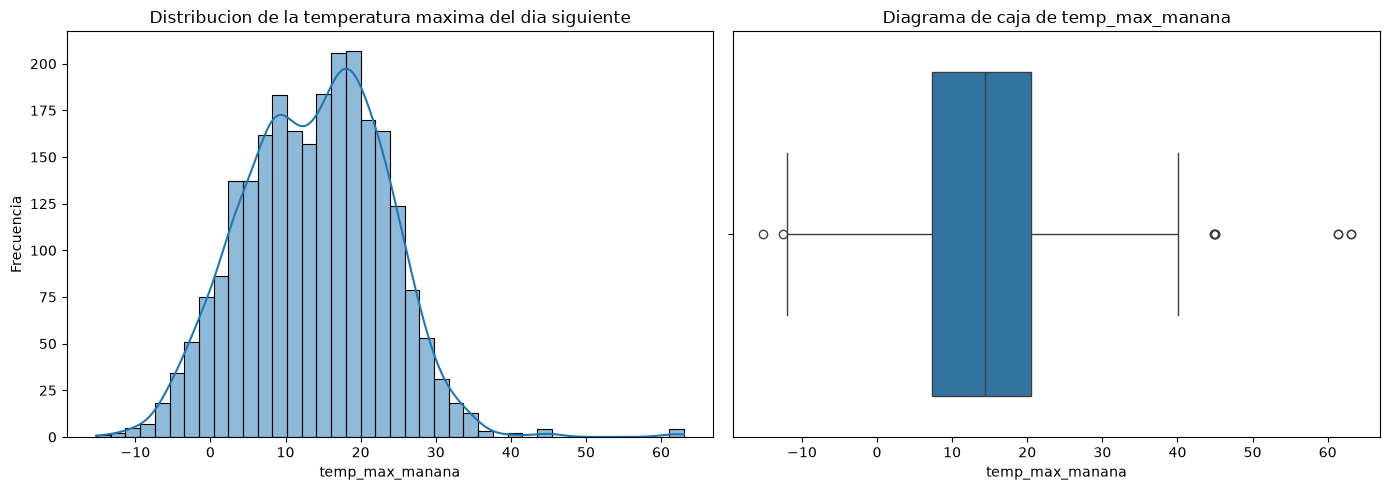

In [106]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(x=data['temp_max_manana'], kde=True, bins=40)
plt.title('Distribucion de la temperatura maxima del dia siguiente')
plt.xlabel('temp_max_manana')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['temp_max_manana'])
plt.title('Diagrama de caja de temp_max_manana')
plt.xlabel('temp_max_manana')

plt.tight_layout()
plt.show()

**Interpretación:** 

La distribución es aproximadamente simétrica y ligeramente bimodal, con la
masa de los datos entre −5 y 35, rango consistente con el clima templado continental de Jena.
La media (13,86) y la mediana (14,31) son muy cercanas, lo que descarta una asimetría marcada.
La bimodalidad no es un problema de calidad: refleja el ciclo estacional, ya que los días de
invierno y los de verano forman dos concentraciones naturales.

El diagrama de caja sí revela un problema: un grupo reducido de valores atípicos por encima de
40, que no corresponden al clima de la región.

## 7. Cobertura temporal de los conjuntos

In [107]:
print("Registros por anio en el conjunto de entrenamiento:")
print(data['anio'].value_counts().sort_index())
print()
print("Anios presentes en el conjunto de prueba:", test['anio'].unique())
print()
print("Formato de fecha en entrenamiento:", data['fecha'].dropna().iloc[0])
print("Formato de fecha en prueba       :", test['fecha'].dropna().iloc[0])

Registros por anio en el conjunto de entrenamiento:
anio
2009.0    356
2010.0    358
2011.0    355
2012.0    356
2013.0    356
2014.0    355
2015.0    354
Name: count, dtype: int64

Anios presentes en el conjunto de prueba: [2016]

Formato de fecha en entrenamiento: 2009-01-01
Formato de fecha en prueba       : 01.01.2016


**Interpretación:** 

El entrenamiento cubre 2009-2015 con aproximadamente 355 registros por año, o sea, siete ciclos anuales completos, suficientes para que un modelo pueda aprender el patrón estacional de forma estable. El conjunto de prueba corresponde íntegramente a 2016: la partición es temporalmente posterior, así que el modelo debe predecir un año que nunca ha visto.

Encontramos además una inconsistencia de formato entre archivos: el entrenamiento usa `AAAA-MM-DD` y la prueba usa `DD.MM.AAAA`. Debe corregirse explícitamente antes de trabajar con la fecha, o los días de la prueba se interpretarían mal (por ejemplo, `03.01.2016` se leería como 1 de marzo en lugar de 3 de enero).

## 8. Análisis de calidad de los datos

### 8.1 Completitud - ¿faltan datos?

In [108]:
nulos = pd.DataFrame({
    'nulos': data.isnull().sum(),
    'porcentaje': (data.isnull().sum() / data.shape[0] * 100).round(2)
}).sort_values('nulos', ascending=False)

print(nulos)

                   nulos  porcentaje
temp_max_manana       95        3.69
viento_min            91        3.53
estacion_anio         88        3.42
mes                   88        3.42
anio                  86        3.34
humedad_max           86        3.34
viento_media          86        3.34
viento_max            81        3.14
humedad_min           80        3.11
viento_norte          80        3.11
presion_desv          80        3.11
rafaga_desv           79        3.07
direccion_viento      79        3.07
rafaga_media          78        3.03
registros_del_dia     77        2.99
presion_media         75        2.91
presion_min           74        2.87
humedad_media         74        2.87
rafaga_max            73        2.83
rafaga_min            72        2.80
viento_desv           72        2.80
fecha                 72        2.80
sector_viento         71        2.76
dia_del_anio          68        2.64
presion_max           64        2.48
viento_este           64        2.48
h

In [109]:
print(f"Total de celdas nulas        : {data.isnull().sum().sum()} de {data.size} "
      f"({data.isnull().sum().sum() / data.size * 100:.2f}%)")
print(f"Filas con al menos un nulo   : {data.isnull().any(axis=1).sum()} "
      f"({data.isnull().any(axis=1).mean() * 100:.1f}% de las filas)")
print(f"Filas sin ningun nulo        : {(~data.isnull().any(axis=1)).sum()}")
print()
print(f"Valores nulos en el conjunto de prueba: {test.isnull().sum().sum()}")

Total de celdas nulas        : 2094 de 69552 (3.01%)
Filas con al menos un nulo   : 1454 (56.4% de las filas)
Filas sin ningun nulo        : 1122

Valores nulos en el conjunto de prueba: 0


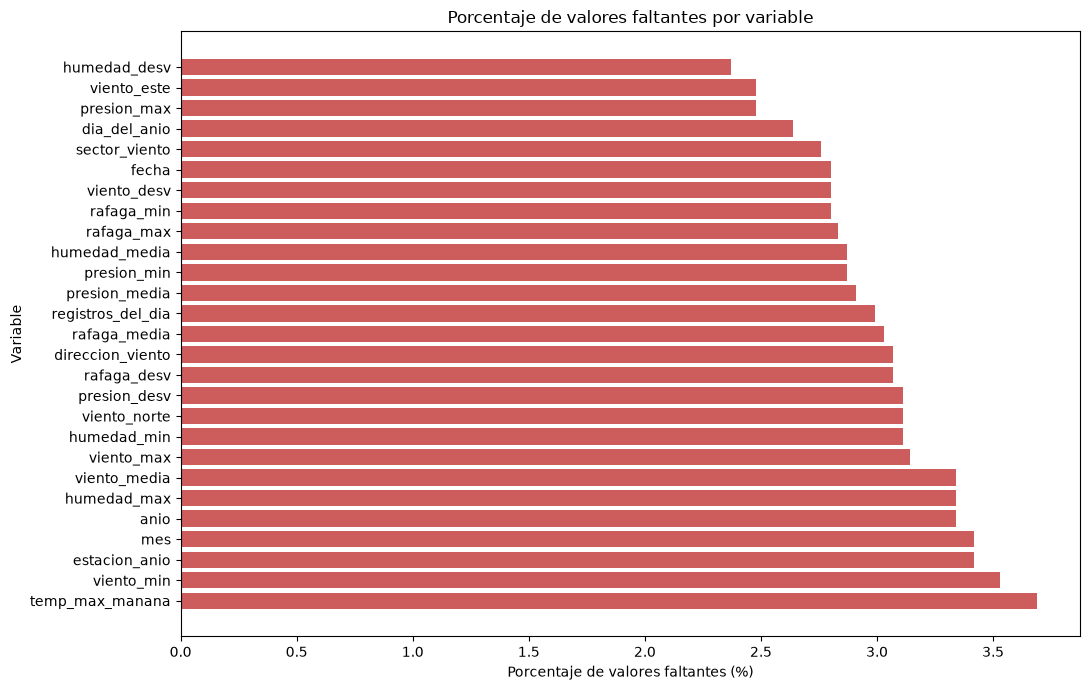

In [110]:
plt.figure(figsize=(11, 7))
plt.barh(nulos.index, nulos['porcentaje'], color='indianred')
plt.title('Porcentaje de valores faltantes por variable')
plt.xlabel('Porcentaje de valores faltantes (%)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

**Interpretación:** 

Los valores faltantes representan el 3,01% de las celdas y están
repartidos de forma homogénea entre todas las columnas (entre 2,37% y 3,69%). Esa
homogeneidad sugiere un mecanismo de pérdida aleatorio y no el fallo sistemático de un sensor
específico. 

El dato decisivo, sin embargo, es otro: aunque solo falta el 3% de las celdas, como los
faltantes están dispersos, el 56,4% de las filas tiene al menos un nulo. Eliminar las
filas incompletas reduciría el conjunto de 2.576 a 1.122 registros, perdiendo más de la mitad
de la información por causa de celdas aisladas.

Un caso requiere tratamiento distinto: `temp_max_manana` tiene 95 valores faltantes. Como es la
variable objetivo, no puede imputarse una etiqueta inventada, pues le enseñaría al modelo una
relación que no existe, por lo que esas filas deberán eliminarse.

El conjunto de prueba no presenta valores faltantes.

### 8.2 Unicidad - ¿hay registros repetidos?

Revisamos los dos tipos de duplicados vistos en el curso: filas idénticas y duplicados lógicos, o sea, filas que no son idénticas pero representan la misma entidad según la lógica del negocio. Como se estableció en la sección 3, cada fila resume un día en una única estación, por lo que no puede existir más de una fila con la misma `fecha`.

In [111]:
print("Filas completamente identicas         :", data.duplicated().sum())
print("Fechas repetidas                      :", data['fecha'].duplicated().sum())
print("Fechas unicas                         :", data['fecha'].nunique())
print("Filas involucradas en fechas repetidas:", data['fecha'].duplicated(keep=False).sum())
print()
print("Fechas repetidas en el conjunto de prueba:", test['fecha'].duplicated().sum())

Filas completamente identicas         : 4
Fechas repetidas                      : 89
Fechas unicas                         : 2486
Filas involucradas en fechas repetidas: 108

Fechas repetidas en el conjunto de prueba: 0


In [112]:
fechas_rep = data[data['fecha'].duplicated(keep=False)].sort_values('fecha')
fechas_rep[['fecha', 'presion_media', 'humedad_media', 'viento_media', 'temp_max_manana']].head(10)

,fecha,presion_media,humedad_media,viento_media,temp_max_manana
21,2009-01-22,9784.115000,86.731100,10.09692,5.770000
2563,2009-01-22,9784.115000,86.731100,10.09692,5.770000
63,2009-03-05,959.860700,94.294400,1.29080,5.370000
2574,2009-03-05,959.860700,NaN,1.29080,5.956009
121,2009-05-02,998.118900,77.500000,1.84440,20.890000
2568,2009-05-02,998.855231,77.500000,1.84440,20.890000
341,2009-12-08,983.849000,0.877951,4.53492,7.120000
2575,2009-12-08,983.849000,1.021309,4.53492,7.120000
590,2010-08-14,990.482800,84.386400,1.70860,19.500000
2566,2010-08-14,991.272748,84.386400,1.70860,19.500000


**Interpretación:** 

Existen 4 filas completamente idénticas y 89 fechas repetidas, que
involucran 108 filas del conjunto (algunas fechas aparecen incluso tres veces).

Al inspeccionar los pares se observa que no todos son copias exactas, algunos difieren en
unos pocos decimales y otros presentan un nulo donde el registro gemelo tiene valor. Esto
corresponde al segundo tipo de duplicidad: registros que la lógica del negocio identifica como
el mismo hecho aunque los valores almacenados difieran. Como un mismo día no puede haber sido
observado dos veces por la misma estación, se trata de duplicados y no de información adicional.

El conjunto de prueba no presenta fechas repetidas.

### 8.3 Consistencia - ¿el mismo concepto está escrito igual siempre?

#### 8.3.1 Variables cualitativas

In [113]:
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f"===== {col}: {data[col].nunique()} valores distintos =====")
    print(data[col].value_counts(dropna=False).head(15))
    print("(se muestran los 15 mas frecuentes)")
    print()

===== estacion_anio: 28 valores distintos =====
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
Name: count, dtype: int64
(se muestran los 15 mas frecuentes)

===== mes: 61 valores distintos =====
mes
May          127
August       125
July         123
January      120
March        118
December     115
September    114
October      112
June         110
November     105
February     101
April         90
NaN           88
NOVEMBER      32
diciembre     32
Name: count, dtype: int64
(se muestran los 15 mas frecuentes)

===== sector_viento: 33 valores distintos =====
sector_viento
SO           695
S            519

In [114]:
resumen_cat = pd.DataFrame({
    'variable': ['estacion_anio', 'mes', 'sector_viento'],
    'observadas_en_train': [data[c].nunique() for c in ['estacion_anio', 'mes', 'sector_viento']],
    'observadas_en_test': [test[c].nunique() for c in ['estacion_anio', 'mes', 'sector_viento']],
    'esperadas': [4, 12, 8]
})
print(resumen_cat.to_string(index=False))

     variable  observadas_en_train  observadas_en_test  esperadas
estacion_anio                   28                   4          4
          mes                   61                  12         12
sector_viento                   33                   8          8


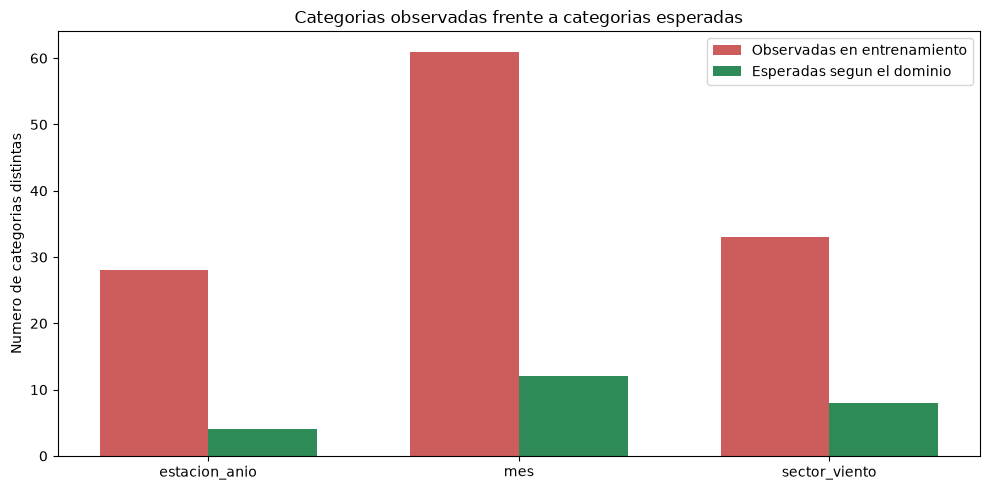

In [115]:
x = np.arange(len(resumen_cat))
ancho = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - ancho/2, resumen_cat['observadas_en_train'], ancho,
        color='indianred', label='Observadas en entrenamiento')
plt.bar(x + ancho/2, resumen_cat['esperadas'], ancho,
        color='seagreen', label='Esperadas segun el dominio')
plt.xticks(x, resumen_cat['variable'])
plt.title('Categorias observadas frente a categorias esperadas')
plt.ylabel('Numero de categorias distintas')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:** 

Las tres variables cualitativas presentan una inconsistencia severa: 122
categorías observadas frente a 24 esperadas.

1. `estacion_anio`: 28 categorías para 4 estaciones. Se combinan diferencias de
  capitalización (`VERANO`, `Verano`, `verano`), idiomas (`winter`, `autumn`, `spring`),
  presencia y ausencia de tildes (`otoño` / `otono`), errores de digitación (`berano`,
  `invernio`, `primaveraa`) y categorías inexistentes en el dominio (`Inverano`,
  `VERANO_INVIERNO`, `Estacion_Desconocida`). Especialmente grave: el valor `East` aparece 48
  veces, y no es una estación del año sino un sector de viento, lo que indica contaminación
  entre columnas al construir el archivo.
2. `mes`: 61 categorías para 12 meses, mezclando inglés y español (`January` / `enero`),
  mayúsculas (`NOVEMBER`) y abreviaturas (`Feb`, `Nov`, `Sep`).
3. `sector_viento`: 33 categorías para 8 sectores, donde un mismo sector aparece como `SO`,
  `so`, `Suroeste` y `SOUTHWEST`.

El conjunto de prueba presenta exactamente 4, 12 y 8 categorías, todas correctamente escritas. 

Estas tres columnas mostradas son derivables de otras columnas del mismo conjunto (`mes` y `estacion_anio` de `fecha`, y `sector_viento` de `direccion_viento`), lo que evita tener que decidir arbitrariamente a qué categoría corresponden valores como `VERANO_INVIERNO`.

#### 8.3.2 Consistencia de escalas

La consistencia no aplica solo al texto: una misma magnitud registrada en unidades distintas
dentro de la misma columna es también un problema de consistencia, y es más difícil de
detectar porque los valores son numéricamente válidos.

In [116]:
for col in ['humedad_media', 'humedad_min', 'humedad_max']:
    en_proporcion = (data[col] <= 1.5).sum()
    no_nulos = data[col].notna().sum()
    print(f"{col}: {en_proporcion} de {no_nulos} registros con valor <= 1.5 "
          f"({en_proporcion / no_nulos * 100:.1f}%)")

print()
print(f"Rango de humedad_media en entrenamiento: "
      f"{data['humedad_media'].min():.4f} a {data['humedad_media'].max():.2f}")
print(f"Rango de humedad_media en prueba       : "
      f"{test['humedad_media'].min():.2f} a {test['humedad_media'].max():.2f}")

humedad_media: 778 de 2502 registros con valor <= 1.5 (31.1%)
humedad_min: 626 de 2496 registros con valor <= 1.5 (25.1%)
humedad_max: 0 de 2490 registros con valor <= 1.5 (0.0%)

Rango de humedad_media en entrenamiento: 0.0047 a 100.00
Rango de humedad_media en prueba       : 44.42 a 98.34


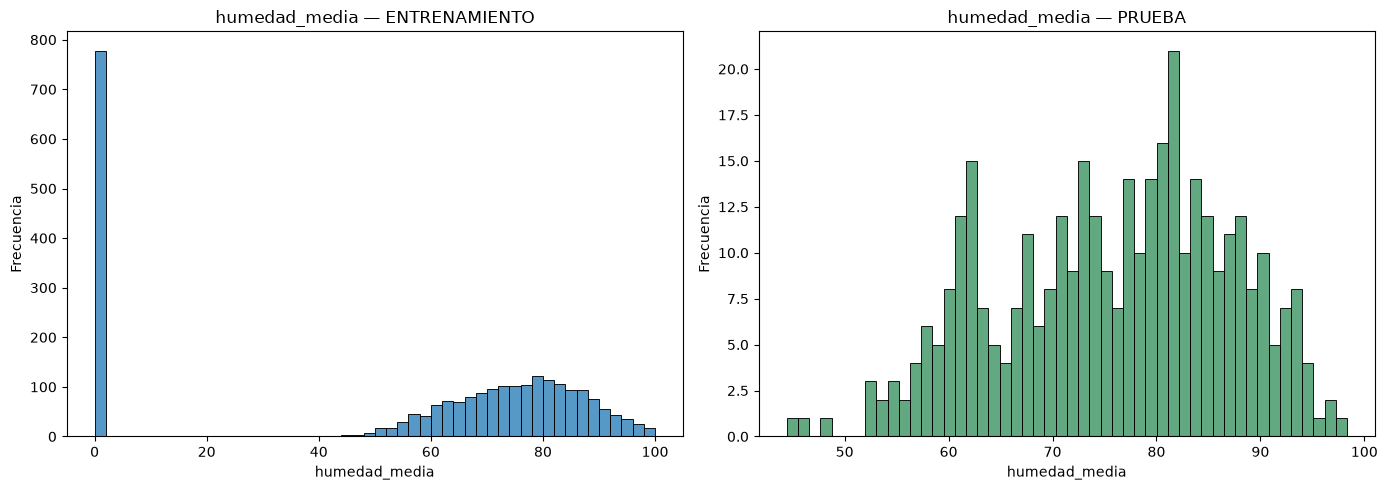

In [117]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(x=data['humedad_media'], bins=50)
plt.title('humedad_media — ENTRENAMIENTO')
plt.xlabel('humedad_media')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(x=test['humedad_media'], bins=50, color='seagreen')
plt.title('humedad_media — PRUEBA')
plt.xlabel('humedad_media')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Interpretación:**

El histograma del entrenamiento muestra una distribución bimodal
artificial: una masa cerca de 0 y otra entre 60 y 100. No son dos regímenes climáticos sino
dos unidades de medida conviviendo en la misma columna: aproximadamente el 31% de los
registros está expresado como proporción (0-1) y el resto como porcentaje (0-100).

El histograma de la prueba confirma el diagnóstico: allí todo está en porcentaje y la
distribución es unimodal asimétrica, que es la forma esperada de la humedad relativa en un
clima templado.

Esta mezcla es especialmente dañina en regresión lineal, ya que el modelo estima un único
coeficiente por variable y no puede representar dos unidades a la vez: un mismo día con 90%
de humedad aportaría al ajuste como `0.9` o como `90` según el registro.

### 8.4 Validez - ¿los valores están dentro del rango posible?

Se contrasta cada variable contra el dominio definido en el diccionario de la sección 4.

In [118]:
print("=== 1. Presion fuera del rango atmosferico plausible [900, 1050] hPa ===")
for col in ['presion_media', 'presion_min', 'presion_max']:
    print(f"   {col}: {((data[col] > 1050) | (data[col] < 900)).sum()} registros")
print()
print(data.loc[data['presion_media'] > 2000,
               ['fecha', 'presion_media', 'presion_min', 'presion_max']].to_string(index=False))

=== 1. Presion fuera del rango atmosferico plausible [900, 1050] hPa ===
   presion_media: 6 registros
   presion_min: 0 registros
   presion_max: 0 registros

     fecha  presion_media  presion_min  presion_max
2009-01-22       9784.115       971.48       983.54
2010-10-25       9928.772       986.97       998.17
2013-01-02       9939.918       985.61      1001.18
2013-01-02       9939.918       985.61      1001.18
2010-10-25       9928.772       986.97       998.17
2009-01-22       9784.115       971.48       983.54


In [119]:
print("=== 2. Humedad fuera del dominio [0, 100] % ===")
for col in ['humedad_media', 'humedad_min', 'humedad_max']:
    print(f"   {col}: {(data[col] > 100).sum()} registros mayores a 100")
print()

print("=== 3. Valores centinela (menores o iguales a -999) ===")
for col in data.select_dtypes(include=np.number).columns:
    n = (data[col] <= -999).sum()
    if n > 0:
        print(f"   {col}: {n} registro(s). Valor(es): {data.loc[data[col] <= -999, col].tolist()}")
print()

print("=== 4. Velocidades negativas (fisicamente imposibles) ===")
for col in ['viento_media', 'viento_min', 'viento_max',
            'rafaga_media', 'rafaga_min', 'rafaga_max']:
    n = (data[col] < 0).sum()
    if n > 0:
        print(f"   {col}: {n} registro(s)")
print()

print("=== 5. registros_del_dia distinto de 144 ===")
print(data['registros_del_dia'].value_counts(dropna=False).sort_index().to_string())

=== 2. Humedad fuera del dominio [0, 100] % ===
   humedad_media: 0 registros mayores a 100
   humedad_min: 23 registros mayores a 100
   humedad_max: 0 registros mayores a 100

=== 3. Valores centinela (menores o iguales a -999) ===
   rafaga_media: 1 registro(s). Valor(es): [-1386.2733]
   rafaga_min: 1 registro(s). Valor(es): [-9999.0]
   viento_norte: 1 registro(s). Valor(es): [-1250.4633]

=== 4. Velocidades negativas (fisicamente imposibles) ===
   rafaga_media: 1 registro(s)
   rafaga_min: 1 registro(s)

=== 5. registros_del_dia distinto de 144 ===
registros_del_dia
90.0        1
103.0       1
142.0       1
143.0       3
144.0    2489
145.0       1
222.0       1
249.0       1
287.0       1
NaN        77


**Interpretación:**

1. Presión (6 registros). Valores cercanos a 9.800–9.900 hPa. Como `presion_min` y `presion_max` de esas mismas filas están en rango normal, se descarta un fenómeno real y se identifica un error de escala por factor 10 al registrar el promedio.
2. Humedad (23 registros). Valores como 103,31%. La humedad relativa está acotada al 100% por definición, así que se trata de un error de registro.
3. Valores centinela (3 registros). `-9999` en `rafaga_media`, `rafaga_min` y `viento_norte`. Es la convención habitual para indicar "sin dato" en sistemas de adquisición meteorológica: deben leerse como faltantes, no como números, ya que de lo contrario distorsionarían gravemente la media y la desviación estándar de esas columnas.
4. `registros_del_dia`. 2.489 días tienen los 144 registros esperados, pero unos pocos presentan valores como 90, 103, 222, 249 o 287. Los valores bajos indican días con mediciones perdidas, y valores como 287 (aproximadamente 2 × 144) sugieren días agregados dos veces, lo cual es coherente con las fechas duplicadas de la sección 8.2.

#### 8.4.1 Validez de la variable objetivo: unidades de temperatura

El diagrama de caja de la sección 6 mostró valores por encima de 40. Los inspeccionamos junto
con su fecha.

In [120]:
sospechosos = data[data['temp_max_manana'] > 38].copy()
sospechosos['si_fuera_fahrenheit'] = ((sospechosos['temp_max_manana'] - 32) * 5 / 9).round(2)

print(f"Registros con temp_max_manana mayor a 38: {len(sospechosos)}")
print()
print(sospechosos[['fecha', 'temp_max_manana',
                   'si_fuera_fahrenheit']].sort_values('temp_max_manana').to_string(index=False))

Registros con temp_max_manana mayor a 38: 10

     fecha  temp_max_manana  si_fuera_fahrenheit
       NaN           40.118                 4.51
2014-12-05           40.118                 4.51
2012-11-13           44.852                 7.14
2012-11-13           44.852                 7.14
2015-01-07           44.978                 7.21
2015-01-07           44.978                 7.21
2013-04-20           61.412                16.34
2013-04-20           61.412                16.34
2012-10-04           63.050                17.25
2012-10-04           63.050                17.25


**Interpretación:** 

Los 10 registros con temperatura superior a 38 no corresponden a un evento
climático extremo: son valores expresados en grados Fahrenheit dentro de una columna en
grados Celsius. Dos evidencias independientes lo confirman:

1. **Aritmética:** Al aplicar la conversión `(°F − 32) × 5/9` producen temperaturas entre 4 y
   17 grados, perfectamente normales para la región.
2. **Contextual:** Las fechas asociadas caen en enero, abril, octubre y diciembre. Una
   temperatura de 44 o 63 grados es imposible en Jena en esos meses, mientras que 7 o 17 es
   exactamente lo esperado. Si los valores fueran reales, se concentrarían en julio y agosto.

Este caso muestra por qué conviene entender la causa de un problema antes de decidir cómo
tratarlo: leídos como simples valores atípicos, estos 10 registros se habrían eliminado
perdiendo información válida.

#### 8.4.2 Coherencia lógica dentro de las familias de variables

Cada familia contiene el mínimo, la media y el máximo del mismo día, por lo que debe cumplirse
`min ≤ media ≤ max`. La verificación se aplica a `presion`, `viento` y `rafaga`. Se excluye
`humedad` porque su comparación quedaría distorsionada por la mezcla de escalas documentada en
la sección 8.3.2, y homogeneizarla aquí sería corregir el dato en lugar de diagnosticarlo.

In [121]:
filas = []
for fam in ['presion', 'viento', 'rafaga']:
    mn = data[f'{fam}_min']
    me = data[f'{fam}_media']
    mx = data[f'{fam}_max']
    incoherentes = (mn > mx)
    media_en_medio = ((me >= mx) & (me <= mn) & incoherentes).sum()
    filas.append({
        'familia': fam,
        'filas_con_min_mayor_que_max': int(incoherentes.sum()),
        'porcentaje': round(incoherentes.sum() / data.shape[0] * 100, 2),
        'de_esas_la_media_queda_en_medio': int(media_en_medio)
    })

print(pd.DataFrame(filas).to_string(index=False))

familia  filas_con_min_mayor_que_max  porcentaje  de_esas_la_media_queda_en_medio
presion                          121        4.70                              117
 viento                          120        4.66                              115
 rafaga                          122        4.74                              119


In [122]:
print("Ejemplos de la familia 'viento' donde min > max:")
print(data.loc[data['viento_min'] > data['viento_max'],
               ['viento_min', 'viento_media', 'viento_max']].head(8).to_string())

Ejemplos de la familia 'viento' donde min > max:
     viento_min  viento_media  viento_max
17    34.953763      10.70604    0.684000
22    12.536035       5.10390    1.137109
32     9.119714       1.48330    0.037282
103   23.568189       5.45436    0.000000
120    9.008852       1.56780    0.070000
123    5.483040       1.71510    0.210000
135    8.204953       2.14320    0.037282
201    7.787831       1.95880    0.031069


**Interpretación:**

Alrededor del 4,7% de las filas de cada familia viola la relación
`min ≤ media ≤ max`. Al inspeccionar los casos concretos aparece un patrón muy claro: en más
del 95% de ellos la media queda entre los otros dos valores, lo que indica que las columnas
`min` y `max` están intercambiadas, no corrompidas. El ejemplo de la tabla lo muestra: una fila con `viento_min = 34,95`, `viento_media = 10,71` y
`viento_max = 0,68` es incoherente tal como está, pero al intercambiar mínimo y máximo se
obtiene `0,68 ≤ 10,71 ≤ 34,95`, una tripleta válida. Se trata, por tanto, de un problema de
orden de columnas y no de valores erróneos.

### 8.5 Valores atípicos

Se usan diagramas de caja agrupados por familia, ya que es el gráfico apropiado para variables
cuantitativas continuas y permite identificar los puntos fuera de 1,5 veces el rango
intercuartílico.

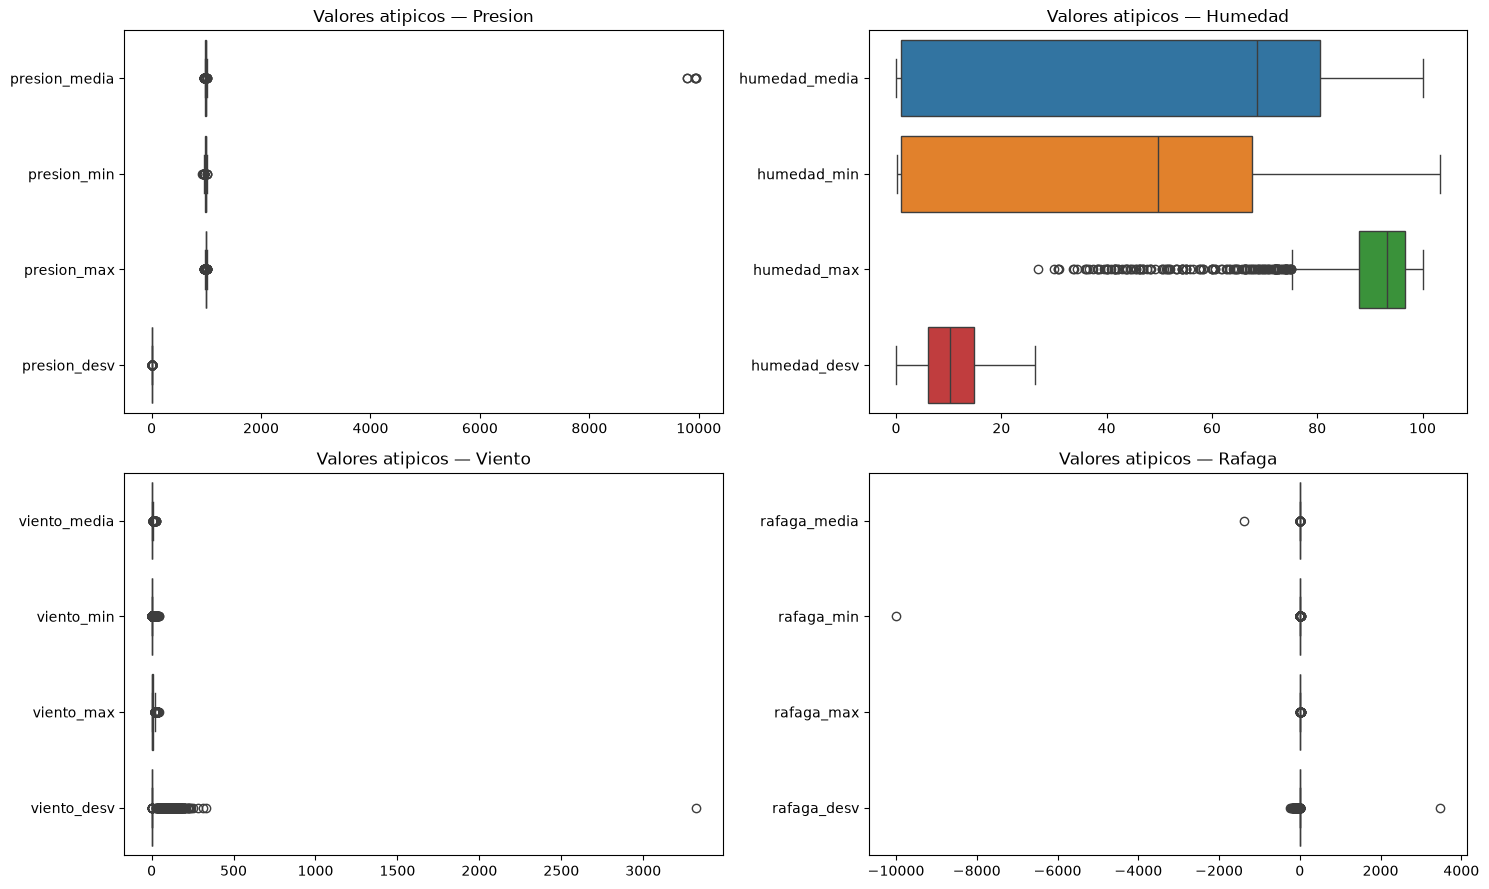

In [123]:
familias = {
    'Presion': ['presion_media', 'presion_min', 'presion_max', 'presion_desv'],
    'Humedad': ['humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv'],
    'Viento':  ['viento_media', 'viento_min', 'viento_max', 'viento_desv'],
    'Rafaga':  ['rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv'],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (titulo, cols) in zip(axes.ravel(), familias.items()):
    sns.boxplot(data=data[cols], orient='h', ax=ax)
    ax.set_title(f'Valores atipicos — {titulo}')
plt.tight_layout()
plt.show()

**Interpretación:** 

La escala de varias variables está completamente dominada por unos pocos puntos extremos: `viento_desv` y `rafaga_desv` alcanzan valores cercanos a 3.300, mientras que `rafaga_media` y `viento_norte` descienden hasta -1.300. Son valores físicamente imposibles: la ráfaga de viento más intensa registrada en la superficie terrestre no alcanza los 115 m/s, y una velocidad negativa carece de sentido físico.

Hay que distinguir dos tipos de valores atípicos, porque no significan lo mismo:

| Tipo | Ejemplo en este conjunto | Qué representa |
|---|---|---|
| **Atípico legítimo** | Un día de tormenta con `viento_max` de 24 m/s | Información real y valiosa: son justamente los días extremos que interesan al problema de negocio |
| **Atípico imposible** | `rafaga_desv` de 3.471, centinelas `-9999` | Error de registro, no fenómeno meteorológico |

La distinción importa especialmente en este caso: AlpesPlanck quiere anticipar situaciones extremas, así que descartar todos los días atípicos eliminaría precisamente los casos de mayor interés para la institución.

## 9. Relación entre las variables y la variable objetivo

Para explorar la relación entre dos variables cuantitativas, el gráfico apropiado es el
diagrama de dispersión. Se examinan la humedad media, variable meteorológica, y el día del
año, variable temporal, frente a la variable objetivo.

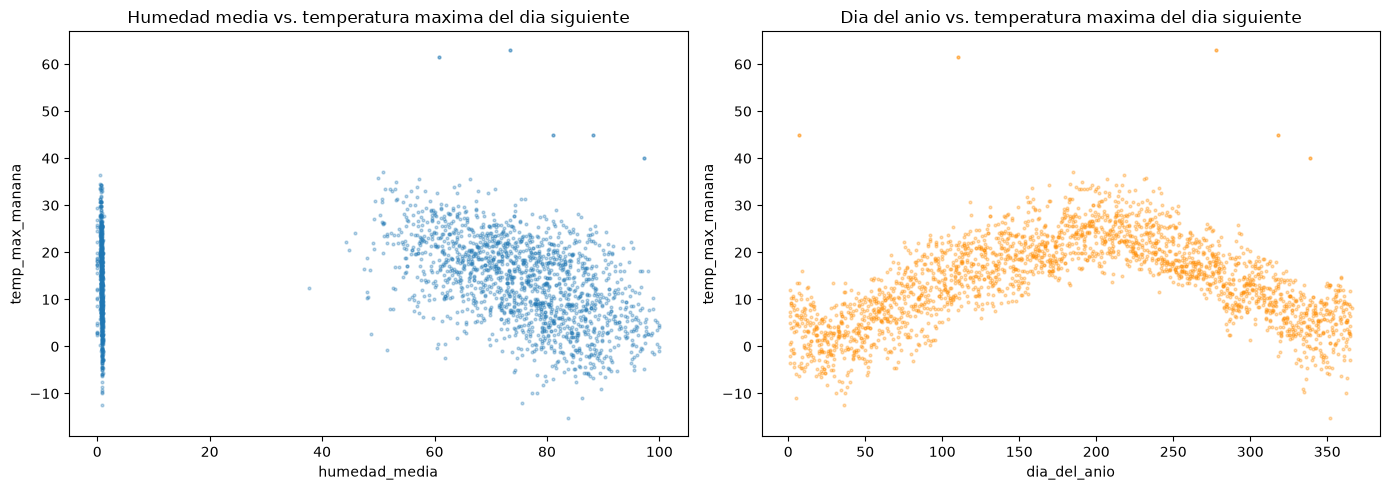

In [124]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(data['humedad_media'], data['temp_max_manana'], '.', alpha=0.3, markersize=4)
plt.title('Humedad media vs. temperatura maxima del dia siguiente')
plt.xlabel('humedad_media')
plt.ylabel('temp_max_manana')

plt.subplot(1, 2, 2)
plt.plot(data['dia_del_anio'], data['temp_max_manana'], '.', alpha=0.3,
         markersize=4, color='darkorange')
plt.title('Dia del anio vs. temperatura maxima del dia siguiente')
plt.xlabel('dia_del_anio')
plt.ylabel('temp_max_manana')

plt.tight_layout()
plt.show()

El gráfico de la izquierda muestra una relación negativa y difusa entre humedad y temperatura: los días más húmedos tienden a ser más fríos, lo cual encaja con la física (mayor humedad suele acompañar mayor nubosidad), pero la dispersión es amplia y la relación no es fuerte. Se ve además la separación en dos bloques verticales producida por la mezcla de escalas documentada en la sección 8.3.2.

El gráfico de la derecha es lo más importante que encontramos: la relación entre `dia_del_anio` y la temperatura es muy fuerte y tiene forma de campana (fría en enero, ascendente hasta un máximo en julio, descendente de nuevo hacia diciembre). La nube de puntos dibuja con claridad el ciclo anual.

Esto significa que la variable más informativa del conjunto no es ninguna variable meteorológica sino la posición del día dentro del año, y que esa relación no es lineal. Además, en su forma actual el día 1 y el día 365 son valores numéricos muy distantes, cuando en realidad corresponden a días climáticamente casi idénticos.

## 10. Resumen del análisis de calidad

| # | Dimensión | Problema detectado | Magnitud medida |
|---|---|---|---|
| 1 | Completitud | Valores faltantes en las 27 columnas | 3,01% de las celdas; 56,4% de las filas afectadas |
| 2 | Completitud | Faltantes en la variable objetivo | 95 registros (3,69%) |
| 3 | Unicidad | Filas completamente idénticas | 4 filas |
| 4 | Unicidad | Fechas repetidas | 89 fechas / 108 filas |
| 5 | Consistencia | `estacion_anio` con categorías espurias | 28 observadas vs. 4 esperadas |
| 6 | Consistencia | `mes` con categorías espurias | 61 observadas vs. 12 esperadas |
| 7 | Consistencia | `sector_viento` con categorías espurias | 33 observadas vs. 8 esperados |
| 8 | Consistencia | Humedad en dos escalas (proporción y porcentaje) | ~31% de los registros |
| 9 | Consistencia | Formato de fecha distinto entre archivos | Todo el conjunto de prueba |
| 10 | Validez | Presión con error de escala (factor 10) | 6 registros |
| 11 | Validez | Humedad superior al 100% | 23 registros |
| 12 | Validez | Variable objetivo en grados Fahrenheit | 10 registros |
| 13 | Validez | `min` y `max` intercambiados dentro de cada familia | ~4,7% de las filas por familia |
| 14 | Validez | Valores centinela `-9999` | 3 registros |
| 15 | Validez | `registros_del_dia` distinto de 144 | 9 registros |
| 16 | Atípicos | Valores físicamente imposibles en viento y ráfaga | Decenas de registros |

**Nota sobre el conjunto de prueba.** No presenta ninguno de estos problemas, con la única
excepción del formato de fecha.

## 11. Conclusiones Actividad 1

**Sobre la adecuación de los datos:** Los datos representan adecuadamente el fenómeno: son mediciones directas de la estación de Jena, con granularidad diaria y siete años de cobertura, suficientes para observar el ciclo anual repetido varias veces. La limitación relevante es la ausencia de variables de temperatura entre las predictoras, lo que establece un techo realista de desempeño: no debe esperarse un ajuste perfecto, porque falta el predictor natural del problema.

**Sobre la integridad de los datos:** El conjunto presenta problemas en las cuatro dimensiones (16 problemas distintos documentados en la sección 10), pero todos son corregibles y ninguno obliga a descartar volúmenes importantes de información. Esto se debe a que el análisis se orientó a identificar la *causa* de cada problema en lugar de tratarlo genéricamente como ruido: las temperaturas mayores a 38 no son atípicas sino Fahrenheit, las ~120 filas incoherentes por familia no están corrompidas sino con las columnas intercambiadas, y las categóricas sucias son derivables de columnas limpias del mismo conjunto.

Elementos que condicionan la preparación de los datos. Del análisis se desprenden tres observaciones que la parte siguiente deberá atender:

1. Dado que el 56,4% de las filas tiene al menos un nulo, eliminar filas incompletas reduciría el conjunto a menos de la mitad. La excepción son las 95 filas sin variable objetivo.
2. Las variables cualitativas presentan 122 categorías frente a 24 esperadas, pero las tres son derivables de `fecha` y `direccion_viento`.
3. La señal predictiva más fuerte del conjunto es la posición del día dentro del año, y esa relación no es lineal, por lo que la variable `dia_del_anio` no puede usarse en su forma cruda en un modelo de regresión lineal.

---

# Actividad 2 - Preparación de los datos

En la Actividad 1 identificamos 16 problemas de calidad repartidos en las cuatro dimensiones, sin corregir ninguno. En esta parte se aplican las correcciones y se construye el conjunto de datos que alimentará los modelos de regresión.

Va en dos bloques, siguiendo la estructura vista en el curso:

1. Limpieza de datos ( corregir los problemas detectados), preservando la mayor cantidad de información posible.
2. Ingeniería de características ( construir y transformar variables para representar mejor la información y facilitar el aprendizaje del algoritmo).

### Orden en que se aplican las correcciones

| Orden | Corrección | Por qué va en esa posición |
|---|---|---|
| 1 | **Unicidad** | Elimina filas antes de invertir esfuerzo en corregirlas, y debe ocurrir antes de la partición para evitar fuga de información |
| 2 | **Completitud de la variable objetivo** | Una fila sin etiqueta no sirve para entrenar |
| 3 | **Consistencia** | Homogeneizar unidades y reconstruir categóricas es requisito para que las validaciones de rango tengan sentido |
| 4 | **Validez** | Va al final porque parte de sus correcciones convierte valores imposibles en faltantes |
| 5 | **Completitud del resto de variables** | Se resuelve por imputación dentro del pipeline, ya que estima parámetros a partir de los datos |

Si se corrigiera la validez antes de la consistencia, la verificación `min ≤ media ≤ max` de la
familia `humedad` daría resultados falsos, porque la columna todavía mezclaría proporciones y
porcentajes.

## 2. Punto de partida

La Parte I dejó cargados los conjuntos originales sin modificar. Como las correcciones cambian la
estructura del conjunto, se trabaja sobre una copia llamada `data`, conservando
`datos_originales` para poder comparar el antes y el después.

In [125]:
# Los conjuntos crudos ya fueron cargados en la Parte I
datos_originales = data.copy()
test_original = test.copy()

# Copia de trabajo sobre la que se aplicaran las correcciones
data = datos_originales.copy()

print(f"Entrenamiento original: {datos_originales.shape[0]} filas x {datos_originales.shape[1]} columnas")
print(f"Prueba original       : {test_original.shape[0]} filas x {test_original.shape[1]} columnas")

Entrenamiento original: 2576 filas x 27 columnas
Prueba original       : 364 filas x 26 columnas


## 3. Limpieza de datos

## 3.1 Unicidad

**Problema detectado en actividad 1:** 4 filas completamente idénticas y 89 fechas repetidas que
involucran 108 filas.

**Estrategias posibles para duplicados lógicos:** 

| Situación | Estrategia |
|---|---|
| Filas completamente idénticas | Conservar una sola con `drop_duplicates()` |
| Mismo identificador, datos distintos por actualización | Conservar el registro más reciente |
| Mismo identificador, datos distintos por error de captura | Eliminar ambos si no puede determinarse cuál es correcto |

**Decisión y justificación:** Se conserva el primer registro de cada fecha. Descartamos las
otras dos alternativas porque no existe una marca de tiempo de captura que permita saber cuál
registro es "más reciente", y porque eliminar ambos registros de cada fecha repetida supondría
perder 108 filas cuando las diferencias entre gemelos son de unos pocos decimales.

También se eliminan las filas sin `fecha`: sin ella no es posible ubicar el registro en el
ciclo anual ni verificar su unicidad.

In [126]:
print("ANTES de la correccion de unicidad")
print(f"  Filas            : {data.shape[0]}")
print(f"  Filas identicas  : {data.duplicated().sum()}")
print(f"  Fechas repetidas : {data['fecha'].duplicated().sum()}")
print(f"  Filas sin fecha  : {data['fecha'].isnull().sum()}")

data = data.dropna(subset=['fecha'])
data = data.drop_duplicates()
data = data.drop_duplicates(subset='fecha', keep='first')

print()
print("DESPUES de la correccion de unicidad")
print(f"  Filas            : {data.shape[0]}")
print(f"  Filas identicas  : {data.duplicated().sum()}")
print(f"  Fechas repetidas : {data['fecha'].duplicated().sum()}")

ANTES de la correccion de unicidad
  Filas            : 2576
  Filas identicas  : 4
  Fechas repetidas : 89
  Filas sin fecha  : 72

DESPUES de la correccion de unicidad
  Filas            : 2486
  Filas identicas  : 0
  Fechas repetidas : 0


## 3.2 Completitud de la variable objetivo

**Problema detectado:** 95 registros sin valor en `temp_max_manana`.

**Decisión y justificación:** Se eliminan esas filas. Es la única situación del conjunto en
la que se prefiere eliminar sobre imputar, y la razón es de fondo: `temp_max_manana` es la
variable objetivo. Imputarla equivaldría a inventar la respuesta correcta y luego pedirle al
modelo que la aprenda; los coeficientes se ajustarían hacia un valor que nadie observó,
sesgando la estimación hacia el centro de la distribución.

El costo es bajo y no introduce sesgo: en la Actividad 1 se verificó que los faltantes están repartidos de forma homogénea y no concentrados en un periodo o condición particular.

In [127]:
antes = data.shape[0]
data = data.dropna(subset=['temp_max_manana'])

print(f"Filas antes  : {antes}")
print(f"Filas despues: {data.shape[0]}")
print(f"Eliminadas   : {antes - data.shape[0]}")

Filas antes  : 2486
Filas despues: 2393
Eliminadas   : 93


## 3.3 Consistencia

### 3.3.1 Formato de la fecha

**Problema detectado:** el entrenamiento usa `AAAA-MM-DD` y la prueba usa `DD.MM.AAAA`.

**Decisión:** Se convierte `fecha` a tipo `datetime` indicando explícitamente el formato de cada archivo. Esta operación cambia el tipo de dato, no el contenido.

In [128]:
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')

print("Tipo de la columna fecha:", data['fecha'].dtype)
print("Rango de fechas:", data['fecha'].min().date(), "a", data['fecha'].max().date())

Tipo de la columna fecha: datetime64[us]
Rango de fechas: 2009-01-01 a 2015-12-31


### 3.3.2 Escalas mezcladas en la humedad

**Problema detectado:** alrededor del 31% de los registros de humedad está expresado como proporción (0-1) y el resto como porcentaje (0-100).

**Decisión y justificación:** Multiplicamos por 100 los valores menores o iguales a 1,5. El umbral no es arbitrario: la humedad relativa medida en porcentaje prácticamente nunca baja de ese valor en un clima templado (el mínimo del conjunto de prueba, que está limpio, es 23,6%), mientras que expresada como proporción nunca lo supera. El umbral separa las dos escalas sin dudas.

In [129]:
columnas_humedad = ['humedad_media', 'humedad_min', 'humedad_max']

print("ANTES de homogeneizar la escala")
print(data[columnas_humedad].describe().loc[['min', 'max']].round(4))
print()

for col in columnas_humedad:
    afectados = (data[col] <= 1.5).sum()
    data[col] = np.where(data[col] <= 1.5, data[col] * 100, data[col])
    print(f"{col}: {afectados} registros convertidos de proporcion a porcentaje")

print()
print("DESPUES de homogeneizar la escala")
print(data[columnas_humedad].describe().loc[['min', 'max']].round(4))

ANTES de homogeneizar la escala
     humedad_media  humedad_min  humedad_max
min         0.0047       0.2377        27.02
max       100.0000     103.3114       100.00

humedad_media: 726 registros convertidos de proporcion a porcentaje
humedad_min: 583 registros convertidos de proporcion a porcentaje
humedad_max: 0 registros convertidos de proporcion a porcentaje

DESPUES de homogeneizar la escala
     humedad_media  humedad_min  humedad_max
min         0.4663      12.9500        27.02
max       100.0000     103.3114       100.00


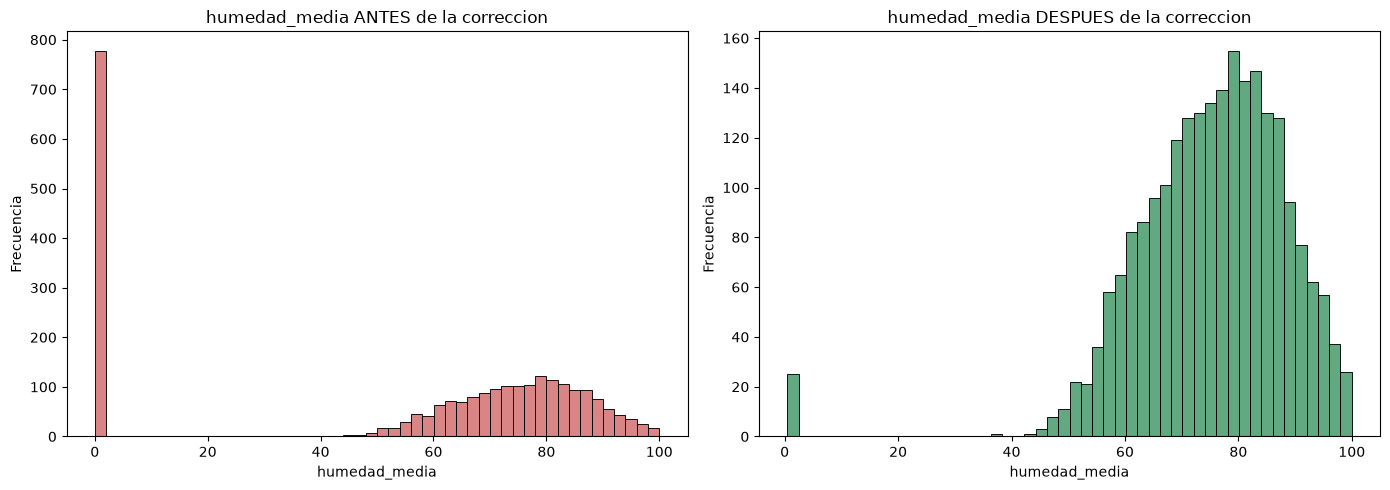

In [130]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(x=datos_originales['humedad_media'], bins=50, color='indianred')
plt.title('humedad_media ANTES de la correccion')
plt.xlabel('humedad_media')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(x=data['humedad_media'], bins=50, color='seagreen')
plt.title('humedad_media DESPUES de la correccion')
plt.xlabel('humedad_media')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 3.3.3 Reconstrucción de las variables cualitativas

**Problema detectado:** `estacion_anio` con 28 categorías, `mes` con 61 y `sector_viento` con 33, frente a 4, 12 y 8 esperadas.

**Estrategias posibles.**

| Alternativa | Descripción | Problema |
|---|---|---|
| Normalizar el texto | Minúsculas, quitar tildes, mapear sinónimos | No resuelve `Inverano`, `VERANO_INVIERNO`, `Estacion_Desconocida` ni `East`; obliga a decidir arbitrariamente |
| Imputar por la moda | Reemplazar las categorías espurias por la más frecuente | Introduce un sesgo grande: asignaría "primavera" a registros de cualquier época |
| Derivar de una columna limpia | Reconstruir a partir de `fecha` y `direccion_viento` | Requiere una relación determinística - que en este caso sí existe |

**Decisión.** Se **derivan** las tres variables. La información necesaria ya está en el
conjunto: la estación y el mes son función de la fecha, y el sector cardinal es función de la
dirección en grados. Ninguna de las tres es información independiente que se pierda al
reconstruirla.

Antes de aplicarlo, verificamos que las reglas son correctas contrastándolas contra el
conjunto de prueba, que en la Parte I se comprobó limpio y con exactamente 4, 12 y 8
categorías bien escritas. Si las reglas reproducen esas columnas, quedan validadas.

In [131]:
meses_es = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
            7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

estaciones = {12: 'invierno', 1: 'invierno', 2: 'invierno',
              3: 'primavera', 4: 'primavera', 5: 'primavera',
              6: 'verano', 7: 'verano', 8: 'verano',
              9: 'otono', 10: 'otono', 11: 'otono'}

# Cada sector cardinal cubre 45 grados centrados en su direccion
cortes = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
sectores = ['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO', 'N']


def derivar_sector(direccion):
    return pd.cut(direccion, bins=cortes, labels=sectores,
                  ordered=False, include_lowest=True).astype(object)


# Validacion de las reglas contra el conjunto de prueba (que esta limpio)
fecha_test = pd.to_datetime(test_original['fecha'], format='%d.%m.%Y')

coincide_mes = (fecha_test.dt.month.map(meses_es) == test_original['mes']).mean()
coincide_est = (fecha_test.dt.month.map(estaciones) == test_original['estacion_anio']).mean()
coincide_sec = (derivar_sector(test_original['direccion_viento']) == test_original['sector_viento']).mean()

print("Validacion de las reglas de derivacion contra el conjunto de prueba:")
print(f"  mes derivado coincide con la columna 'mes'                : {coincide_mes * 100:.1f}%")
print(f"  estacion derivada coincide con 'estacion_anio'            : {coincide_est * 100:.1f}%")
print(f"  sector derivado coincide con 'sector_viento'              : {coincide_sec * 100:.1f}%")

Validacion de las reglas de derivacion contra el conjunto de prueba:
  mes derivado coincide con la columna 'mes'                : 100.0%
  estacion derivada coincide con 'estacion_anio'            : 100.0%
  sector derivado coincide con 'sector_viento'              : 100.0%


**Resultado de la validación:** Las tres reglas reproducen el 100% de los valores del conjunto
de prueba. Esto confirma que la relación es determinística y que la reconstrucción no es una
aproximación sino una recuperación exacta del valor correcto. Procedemos a aplicarlas al
conjunto de entrenamiento.

In [132]:
print("ANTES de la reconstruccion")
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f"  {col}: {data[col].nunique()} categorias, {data[col].isnull().sum()} nulos")

data['mes'] = data['fecha'].dt.month.map(meses_es)
data['estacion_anio'] = data['fecha'].dt.month.map(estaciones)
data['sector_viento'] = derivar_sector(data['direccion_viento'])

print()
print("DESPUES de la reconstruccion")
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f"  {col}: {data[col].nunique()} categorias, {data[col].isnull().sum()} nulos")
print()
print("Categorias resultantes:")
print("  estacion_anio :", sorted(data['estacion_anio'].dropna().unique()))
print("  sector_viento :", sorted(data['sector_viento'].dropna().unique()))

ANTES de la reconstruccion
  estacion_anio: 28 categorias, 84 nulos
  mes: 61 categorias, 86 nulos
  sector_viento: 33 categorias, 65 nulos

DESPUES de la reconstruccion
  estacion_anio: 4 categorias, 0 nulos
  mes: 12 categorias, 0 nulos
  sector_viento: 8 categorias, 73 nulos

Categorias resultantes:
  estacion_anio : ['invierno', 'otono', 'primavera', 'verano']
  sector_viento : ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']


## 3.4 Validez

### 3.4.1 Error de escala en la presión

**Problema detectado:** 6 registros con `presion_media` cercana a 9.800–9.900 hPa, mientras `presion_min` y `presion_max` de esas mismas filas están en rango normal.

**Decisión:** Dividir entre 10 los valores superiores a 2.000 hPa. Se prefiere esto a marcarlos como faltantes porque el diagnóstico identificó la causa exacta y la corrección recupera el valor real en lugar de estimarlo.

In [133]:
afectados = (data['presion_media'] > 2000).sum()
print(f"Registros con presion_media > 2000: {afectados}")
print("Valores antes:", data.loc[data['presion_media'] > 2000, 'presion_media'].round(2).tolist())

data['presion_media'] = np.where(data['presion_media'] > 2000,
                                 data['presion_media'] / 10,
                                 data['presion_media'])

print()
print(f"Rango de presion_media tras la correccion: "
      f"{data['presion_media'].min():.2f} a {data['presion_media'].max():.2f} hPa")

Registros con presion_media > 2000: 3
Valores antes: [9784.12, 9928.77, 9939.92]

Rango de presion_media tras la correccion: 949.00 a 1011.65 hPa


### 3.4.2 Humedad fuera del dominio

**Problema detectado:** registros con humedad relativa superior al 100%.

**Qué hicimos:** Se aplica `clip(upper=100)`. La humedad relativa está acotada al 100% por definición física, y los valores observados apenas lo exceden (máximo 103,3%), lo que apunta a un error de calibración menor y no a un dato completamente inválido. Recortar al límite conserva la información de que se trataba de un día muy húmedo; marcarlo como faltante la perdería.

In [134]:
for col in ['humedad_media', 'humedad_min', 'humedad_max']:
    afectados = (data[col] > 100).sum()
    data[col] = data[col].clip(upper=100)
    print(f"{col}: {afectados} registros recortados a 100")

print()
print(data[['humedad_media', 'humedad_min', 'humedad_max']].describe().loc[['min', 'max']].round(2))

humedad_media: 0 registros recortados a 100
humedad_min: 24 registros recortados a 100
humedad_max: 0 registros recortados a 100

     humedad_media  humedad_min  humedad_max
min           0.47        12.95        27.02
max         100.00       100.00       100.00


### 3.4.3 Unidades de la variable objetivo

**Problema detectado:** 10 registros de `temp_max_manana` expresados en grados Fahrenheit.

**Qué hicimos:** Los convertimos con la fórmula `(°F - 32) × 5/9`. Otra vez es una regla de negocio que sale del diagnóstico: en la Parte I comprobamos por dos vías independientes (aritmética y contextual, revisando los meses de esas fechas) que se trata de una unidad incorrecta y no de valores extremos reales.

El umbral de 38 es conservador: el valor válido más alto del conjunto es 37,01 °C, así que no hay riesgo de convertir por error un dato correcto.

In [135]:
afectados = (data['temp_max_manana'] > 38).sum()
print(f"Registros a convertir: {afectados}")
print("Valores antes:", sorted(data.loc[data['temp_max_manana'] > 38, 'temp_max_manana'].tolist()))

data['temp_max_manana'] = np.where(data['temp_max_manana'] > 38,
                                   (data['temp_max_manana'] - 32) * 5 / 9,
                                   data['temp_max_manana'])

print()
print(f"Rango de temp_max_manana tras la correccion: "
      f"{data['temp_max_manana'].min():.2f} a {data['temp_max_manana'].max():.2f}")

Registros a convertir: 5
Valores antes: [40.118, 44.852, 44.978, 61.412, 63.05]

Rango de temp_max_manana tras la correccion: -15.23 a 37.01


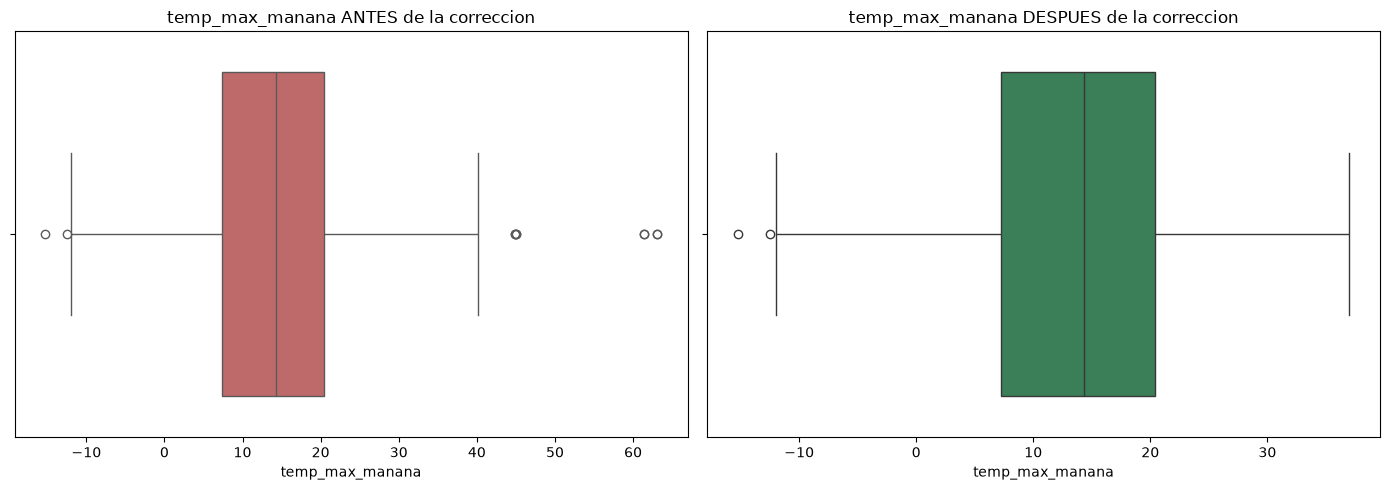

In [136]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=datos_originales['temp_max_manana'], color='indianred')
plt.title('temp_max_manana ANTES de la correccion')
plt.xlabel('temp_max_manana')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['temp_max_manana'], color='seagreen')
plt.title('temp_max_manana DESPUES de la correccion')
plt.xlabel('temp_max_manana')

plt.tight_layout()
plt.show()

El grupo de valores por encima de 40 desaparece y el rango queda contenido dentro de lo climatológicamente posible para Jena. Ningún registro fue eliminado.

### 3.4.4 Columnas `min` y `max` intercambiadas

**Problema detectado:** alrededor del 4,7% de las filas de cada familia viola `min ≤ media ≤ max`, y en más del 95% de los casos la media queda entre los otros dos valores, lo que indica un intercambio de columnas.

**Qué hicimos:** Se reordena la tripleta dentro de cada fila, asignando el menor de los tres valores a `min`, el intermedio a `media` y el mayor a `max`. Preferimos esto a eliminar las filas porque el diagnóstico mostró que los valores son correctos y solo están mal ubicados: se recuperan aproximadamente 120 filas por familia que de otro modo se habrían perdido.

In [137]:
print("ANTES del reordenamiento — filas con min > max:")
for fam in ['presion', 'humedad', 'viento', 'rafaga']:
    print(f"  {fam}: {(data[f'{fam}_min'] > data[f'{fam}_max']).sum()}")

for fam in ['presion', 'humedad', 'viento', 'rafaga']:
    columnas = [f'{fam}_min', f'{fam}_media', f'{fam}_max']
    ordenados = np.sort(data[columnas].values, axis=1)
    data[columnas[0]] = ordenados[:, 0]
    data[columnas[1]] = ordenados[:, 1]
    data[columnas[2]] = ordenados[:, 2]

print()
print("DESPUES del reordenamiento — filas con min > max:")
for fam in ['presion', 'humedad', 'viento', 'rafaga']:
    print(f"  {fam}: {(data[f'{fam}_min'] > data[f'{fam}_max']).sum()}")

ANTES del reordenamiento — filas con min > max:
  presion: 111
  humedad: 113
  viento: 109
  rafaga: 114

DESPUES del reordenamiento — filas con min > max:
  presion: 0
  humedad: 0
  viento: 0
  rafaga: 0


In [138]:
for fam in ['presion', 'humedad', 'viento', 'rafaga']:
    columnas = [f'{fam}_min', f'{fam}_media', f'{fam}_max']
    print(f"{fam}: {data[columnas].isnull().sum().sum()} nulos en la familia. "
          f"Distribucion -> min: {data[columnas[0]].isnull().sum()}, "
          f"media: {data[columnas[1]].isnull().sum()}, "
          f"max: {data[columnas[2]].isnull().sum()}")

presion: 196 nulos en la familia. Distribucion -> min: 0, media: 3, max: 193
humedad: 222 nulos en la familia. Distribucion -> min: 0, media: 3, max: 219
viento: 243 nulos en la familia. Distribucion -> min: 0, media: 8, max: 235
rafaga: 208 nulos en la familia. Distribucion -> min: 0, media: 7, max: 201


El total de nulos por familia se conserva, pero quedan concentrados en la columna `_max`, porque `np.sort` empuja los `NaN` al final de cada fila. Esto es inofensivo para el modelo: el imputador del pipeline tratará cada columna por separado y la cantidad de información faltante es la misma. Se documenta porque explica por qué, en el resumen de la sección 3.5, las columnas `_max` aparecen con más faltantes que las demás.

### 3.4.5 Valores centinela y valores físicamente imposibles

Problema detectado: 3 valores centinela `-9999`, y valores como 3.300 m/s o -1.300 m/s en las variables de viento y ráfaga.

Qué hicimos: Los convertimos a faltantes (`NaN`) para imputarlos posteriormente dentro del pipeline. Preferimos esto a eliminar la fila porque el resto de las mediciones de ese día (presión, humedad, fecha) siguen siendo válidas; eliminar la fila desperdiciaría información correcta por causa de una sola celda errónea.

Los límites se definen a partir del dominio meteorológico y no de un criterio estadístico. Es la misma distinción de la Parte I entre atípico legítimo y atípico imposible: un criterio como el rango intercuartílico eliminaría también los días de tormenta, que son reales y justamente los que interesan al problema de negocio.

In [139]:
limites_fisicos = {
    'presion_media': (900, 1050), 'presion_min': (900, 1050), 'presion_max': (900, 1050),
    'presion_desv': (0, 30),
    'humedad_desv': (0, 50),
    'viento_media': (0, 50), 'viento_min': (0, 50), 'viento_max': (0, 60), 'viento_desv': (0, 30),
    'rafaga_media': (0, 60), 'rafaga_min': (0, 60), 'rafaga_max': (0, 80), 'rafaga_desv': (0, 30),
    'viento_norte': (-50, 50), 'viento_este': (-50, 50),
    'direccion_viento': (0, 360),
}

total = 0
for col, (minimo, maximo) in limites_fisicos.items():
    fuera = ((data[col] < minimo) | (data[col] > maximo)).sum()
    if fuera > 0:
        print(f"{col:20s}: {fuera:3d} valores fuera de [{minimo}, {maximo}] -> marcados como faltantes")
        total += fuera
    data[col] = data[col].mask((data[col] < minimo) | (data[col] > maximo))

print()
print(f"Total de valores marcados como faltantes: {total}")

viento_desv         : 236 valores fuera de [0, 30] -> marcados como faltantes
rafaga_media        :   1 valores fuera de [0, 60] -> marcados como faltantes
rafaga_min          :   1 valores fuera de [0, 60] -> marcados como faltantes
rafaga_desv         : 236 valores fuera de [0, 30] -> marcados como faltantes
viento_norte        :   1 valores fuera de [-50, 50] -> marcados como faltantes

Total de valores marcados como faltantes: 475


Dos columnas resultan afectadas mucho más que las demás: `viento_desv` y `rafaga_desv`, con más de 250 valores enmascarados cada una (cerca del 10% de la columna). Al tratarse de una proporción alta, verificamos que la decisión sea correcta y no un límite mal elegido, contrastando la distribución del entrenamiento con la del conjunto de prueba, que está limpio.

In [140]:
for col in ['viento_desv', 'rafaga_desv']:
    original = datos_originales[col]
    print(f"{col}")
    print(f"   TRAIN original — mediana: {original.median():.2f}, "
          f"percentil 90: {original.quantile(0.90):.2f}, maximo: {original.max():.2f}")
    print(f"   TRAIN original — valores negativos: {(original < 0).sum()}, "
          f"valores mayores a 10: {(original > 10).sum()}")
    print(f"   TEST (limpio)  — rango observado: {test_original[col].min():.2f} "
          f"a {test_original[col].max():.2f}")
    print()

viento_desv
   TRAIN original — mediana: 1.05, percentil 90: 41.16, maximo: 3319.03
   TRAIN original — valores negativos: 0, valores mayores a 10: 261
   TEST (limpio)  — rango observado: 0.32 a 2.99

rafaga_desv
   TRAIN original — mediana: 1.46, percentil 90: 2.58, maximo: 3471.03
   TRAIN original — valores negativos: 258, valores mayores a 10: 1
   TEST (limpio)  — rango observado: 0.42 a 4.02



Los dos casos son corrupciones reales, no límites mal elegidos:

1. En `viento_desv`, la mediana es cercana a 1 y el conjunto de prueba nunca supera 3, pero el entrenamiento tiene más de 260 valores por encima de 10, llegando hasta 3.319. Es un grupo de valores inflados, bien separado del resto de la distribución.
2. En `rafaga_desv`, la mayoría de los valores afectados son negativos. Una desviación estándar no puede serlo por definición, así que no hay ambigüedad posible.

En ambos casos el valor correcto es irrecuperable (a diferencia de la presión ×10 o de los grados Fahrenheit, donde el diagnóstico permitía deshacer la transformación), por lo que marcarlos como faltantes e imputarlos es la única opción que conserva el resto de la fila.

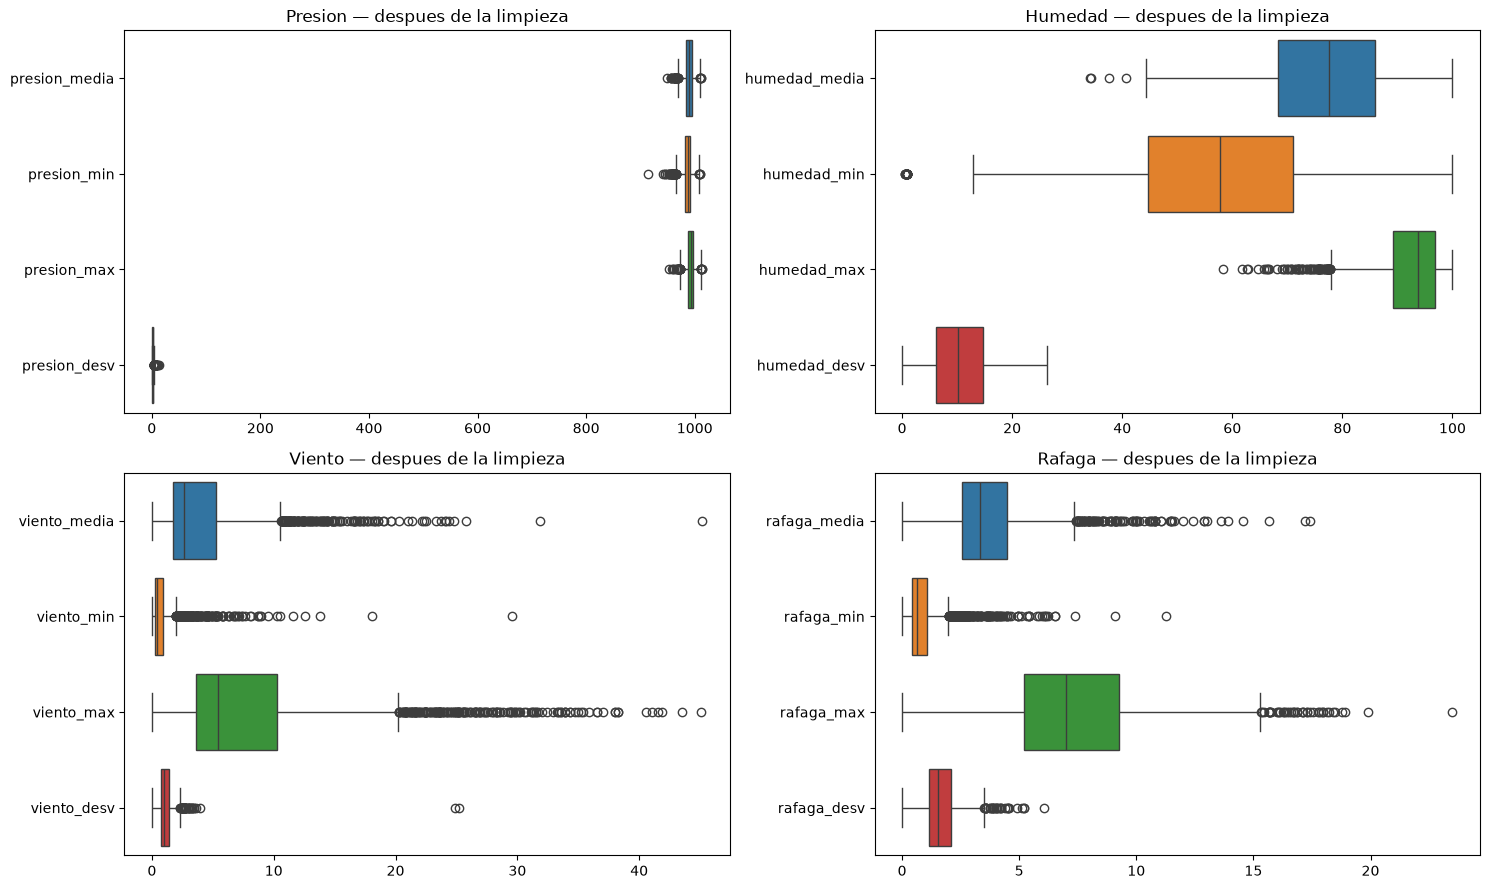

In [141]:
familias = {
    'Presion': ['presion_media', 'presion_min', 'presion_max', 'presion_desv'],
    'Humedad': ['humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv'],
    'Viento':  ['viento_media', 'viento_min', 'viento_max', 'viento_desv'],
    'Rafaga':  ['rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv'],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (titulo, columnas) in zip(axes.ravel(), familias.items()):
    sns.boxplot(data=data[columnas], orient='h', ax=ax)
    ax.set_title(f'{titulo} — despues de la limpieza')
plt.tight_layout()
plt.show()

Comparados con los diagramas de la Parte I, los ejes ya no están dominados por valores extremos y las cajas son legibles. Persisten puntos fuera de los bigotes, lo cual es correcto y deseado: son los atípicos legítimos, días reales de tormenta o de alta presión que el modelo debe poder ver.

## 3.5 Resumen de la limpieza

In [142]:
print("=== Dimensiones ===")
print(f"Filas: {data.shape[0]} (originales: {datos_originales.shape[0]}), Columnas: {data.shape[1]}")
print(f"Filas conservadas: {data.shape[0] / datos_originales.shape[0] * 100:.1f}%")

print("\n=== Unicidad ===")
print(f"Filas identicas : {data.duplicated().sum()}")
print(f"Fechas repetidas: {data['fecha'].duplicated().sum()}")

print("\n=== Consistencia ===")
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f"{col}: {data[col].nunique()} categorias")

print("\n=== Validez ===")
print(f"temp_max_manana en rango [{data['temp_max_manana'].min():.2f}, "
      f"{data['temp_max_manana'].max():.2f}]")
print(f"Humedad maxima: {data[['humedad_media','humedad_min','humedad_max']].max().max():.2f}")
print(f"Filas con min > max: "
      f"{sum((data[f'{f}_min'] > data[f'{f}_max']).sum() for f in ['presion','humedad','viento','rafaga'])}")

print("\n=== Completitud pendiente (se resuelve en el pipeline) ===")
nulos = data.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False))
print(f"\nNulos en la variable objetivo: {data['temp_max_manana'].isnull().sum()}")

=== Dimensiones ===
Filas: 2393 (originales: 2576), Columnas: 27
Filas conservadas: 92.9%

=== Unicidad ===
Filas identicas : 0
Fechas repetidas: 0

=== Consistencia ===
estacion_anio: 4 categorias
mes: 12 categorias
sector_viento: 8 categorias

=== Validez ===
temp_max_manana en rango [-15.23, 37.01]
Humedad maxima: 100.00
Filas con min > max: 0

=== Completitud pendiente (se resuelve en el pipeline) ===
rafaga_desv          310
viento_desv          302
viento_max           235
humedad_max          219
rafaga_max           201
presion_max          193
anio                  79
presion_desv          78
viento_norte          74
registros_del_dia     74
sector_viento         73
direccion_viento      73
dia_del_anio          63
humedad_desv          58
viento_este           56
viento_media           8
rafaga_media           8
presion_media          3
humedad_media          3
rafaga_min             1
dtype: int64

Nulos en la variable objetivo: 0


Las dimensiones de unicidad, consistencia y validez quedan resueltas. La completitud queda parcialmente pendiente de forma deliberada: los valores faltantes de las variables predictoras se imputarán dentro del pipeline, por la razón que se explica en la sección 5. Lo importante es que la variable objetivo ya no tiene ningún nulo.

## 4. Ingeniería de características

Con los datos ya limpios, el siguiente paso es construir y transformar las variables para que el algoritmo pueda consumirlas eficientemente. Se abordan las tres técnicas vistas en el curso:

| Transformación | Por qué es necesaria |
|---|---|
| **Creación de nuevas variables** | Capturar relaciones que las variables originales no expresan directamente |
| **Codificación de variables categóricas** | Los algoritmos trabajan con números, no con cadenas de texto |
| **Escalado** | La regresión lineal es sensible a diferencias de magnitud entre variables |

## 4.1 Creación de nuevas variables: transformaciones temporales

Las variables `mes`, `estacion_anio` y `sector_viento` reconstruidas en la sección 3.3.3 son, en rigor, variables construidas: se derivaron de `fecha` y `direccion_viento`. Esto corresponde a las transformaciones temporales vistas en el curso (extraer el año, el mes o el día a partir de una fecha) y a las combinaciones entre columnas.

Su importancia en este problema es central. En la Parte I comprobamos que la señal más fuerte del conjunto es la posición del día dentro del año, pero que esa relación tiene forma de campana. Una regresión lineal no puede representar una campana con una sola variable numérica; en cambio, sí puede hacerlo si el tiempo se expresa como variable categórica, porque al codificarla el modelo estima un coeficiente independiente para cada categoría y puede subir en unas y bajar en otras.

¿con qué resolución conviene representar el tiempo?

In [143]:
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

print("Resolucion temporal de las variables construidas:")
print(f"  estacion_anio: {data['estacion_anio'].nunique()} categorias (cada una agrupa ~3 meses)")
print(f"  mes          : {data['mes'].nunique()} categorias (cada una agrupa ~30 dias)")
print()
print("Temperatura promedio por estacion:")
print(data.groupby('estacion_anio')['temp_max_manana'].agg(['mean', 'std', 'count']).round(2))
print()
print("Temperatura promedio por mes:")
print(data.groupby('mes')['temp_max_manana'].mean().reindex(orden_meses).round(2))

Resolucion temporal de las variables construidas:
  estacion_anio: 4 categorias (cada una agrupa ~3 meses)
  mes          : 12 categorias (cada una agrupa ~30 dias)

Temperatura promedio por estacion:
                mean   std  count
estacion_anio                    
invierno        3.59  5.34    585
otono          13.66  6.21    592
primavera      14.16  6.48    615
verano         23.20  4.81    601

Temperatura promedio por mes:
mes
January       2.37
February      3.97
March         9.31
April        15.39
May          17.92
June         21.34
July         24.59
August       23.61
September    18.75
October      13.59
November      8.61
December      4.44
Name: temp_max_manana, dtype: float64


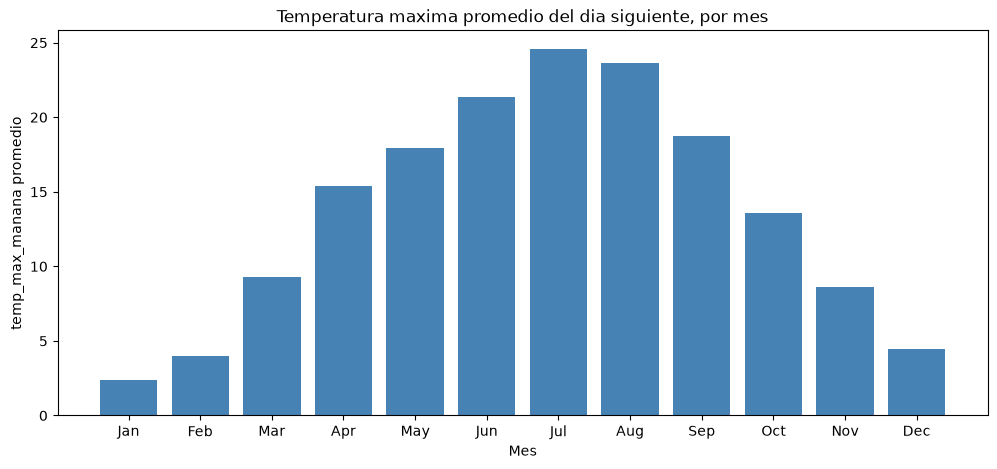

In [144]:
medias_mes = data.groupby('mes')['temp_max_manana'].mean().reindex(orden_meses)

plt.figure(figsize=(12, 5))
plt.bar(range(1, 13), medias_mes.values, color='steelblue')
plt.xticks(range(1, 13), [m[:3] for m in orden_meses])
plt.title('Temperatura maxima promedio del dia siguiente, por mes')
plt.xlabel('Mes')
plt.ylabel('temp_max_manana promedio')
plt.show()

El gráfico muestra por qué la resolución importa. La temperatura promedio de diciembre, enero y febrero es muy similar, así que agruparlos en "invierno" pierde poco. Pero marzo, abril y mayo (los tres "primavera") difieren entre sí en varios grados: al agruparlos, el modelo asigna a los tres el mismo coeficiente y no puede distinguir un día de marzo de uno de mayo. Lo mismo ocurre en otoño, entre septiembre y noviembre.

De aquí salen las dos estrategias de preparación que se definen en la sección 6.

## 4.2 Codificación de variables categóricas

Los algoritmos operan sobre números, así que `mes`, `estacion_anio` y `sector_viento` deben convertirse a una representación numérica. La técnica depende del tipo de variable:

| Técnica | Cuándo usarla |
|---|---|
| Codificación binaria (0/1) | Variable con exactamente 2 categorías |
| Ordinal Encoding | Variable ordinal, con jerarquía entre categorías |
| One-Hot Encoding | Variable nominal con más de 2 categorías |

Qué hicimos: Usamos **One-Hot Encoding** en las tres variables, porque son nominales: aunque existe un orden en el calendario, no hay jerarquía de magnitud entre ellas. Codificar `enero = 1, febrero = 2, ..., diciembre = 12` haría que el modelo interpretara que diciembre "vale doce veces" enero y (peor aún en este problema) que diciembre y enero son los meses más distantes entre sí, cuando climáticamente son casi idénticos.

Ilustramos el resultado sobre una muestra, sin modificar `data`, ya que la codificación definitiva se aplicará dentro del pipeline por las razones de la sección 5.

In [145]:
muestra = data[['estacion_anio']].head(6).copy()
demostracion = pd.get_dummies(muestra, columns=['estacion_anio'], dtype=int)

print("Antes de la codificacion:")
print(muestra.to_string())
print()
print("Despues de One-Hot Encoding:")
print(demostracion.to_string())
print()
print("Columnas binarias que generaria cada variable:")
print(f"  estacion_anio -> {data['estacion_anio'].nunique()}")
print(f"  mes           -> {data['mes'].nunique()}")
print(f"  sector_viento -> {data['sector_viento'].nunique()}")

Antes de la codificacion:
  estacion_anio
0      invierno
1      invierno
2      invierno
3      invierno
4      invierno
6      invierno

Despues de One-Hot Encoding:
   estacion_anio_invierno
0                       1
1                       1
2                       1
3                       1
4                       1
6                       1

Columnas binarias que generaria cada variable:
  estacion_anio -> 4
  mes           -> 12
  sector_viento -> 8


## 4.3 Escalado de variables numéricas

Las variables numéricas tienen magnitudes muy distintas: la presión ronda los 1.000 hPa mientras que la velocidad del viento se mueve entre 0 y 25 m/s. Sin escalado, los coeficientes de la regresión no son comparables entre sí y su magnitud refleja las unidades de cada variable más que su importancia real, lo cual afecta directamente el análisis de importancia de variables que exige el laboratorio.

Qué hicimos: Se aplicará escalado a todas las variables numéricas. Las dos alternativas vistas en el curso:

| Técnica | Fórmula | Resultado |
|---|---|---|
| Min-Max | (x - mín) / (máx - mín) | Valores en el rango [0, 1] |
| Estandarización | (x − μ) / σ | Media 0 y desviación 1 |

Mostramos el efecto sobre una copia; la aplicación definitiva va dentro del pipeline.

In [146]:
columnas_muestra = ['presion_media', 'humedad_media', 'viento_media', 'rafaga_media']

muestra_escalada = data[columnas_muestra].copy()
muestra_escalada = muestra_escalada.fillna(muestra_escalada.median())
muestra_escalada[columnas_muestra] = StandardScaler().fit_transform(muestra_escalada)

print("Estadisticos ANTES del escalado:")
print(data[columnas_muestra].describe().loc[['mean', 'std', 'min', 'max']].round(2))
print()
print("Estadisticos DESPUES de la estandarizacion:")
print(muestra_escalada.describe().loc[['mean', 'std', 'min', 'max']].round(2))

Estadisticos ANTES del escalado:
      presion_media  humedad_media  viento_media  rafaga_media
mean         989.24          76.81          4.11          3.75
std            8.02          11.98          3.78          1.82
min          949.00          34.20          0.00          0.00
max         1011.65         100.00         45.18         17.40

Estadisticos DESPUES de la estandarizacion:
      presion_media  humedad_media  viento_media  rafaga_media
mean          -0.00          -0.00         -0.00          0.00
std            1.00           1.00          1.00          1.00
min           -5.02          -3.56         -1.09         -2.06
max            2.80           1.94         10.89          7.51


## 5. Qué se corrige antes de la partición y qué se corrige dentro del pipeline

Esta es una de las decisiones más importantes de la preparación, y la razón es la fuga de datos (*data leakage*): si una transformación estima parámetros a partir de todo el conjunto antes de dividirlo, el modelo "ve" indirectamente información del conjunto de prueba durante el entrenamiento, lo que infla artificialmente las métricas.

El criterio para decidir es sencillo: ¿la operación aprende algo de los datos?

| Operación | ¿Aprende parámetros? | Dónde va |
|---|---|---|
| Eliminar duplicados | No | Antes de la partición |
| Eliminar filas sin etiqueta | No | Antes de la partición |
| Convertir unidades (Fahrenheit, presión ×10, humedad) | No, es una regla fija | Antes de la partición |
| Reordenar min/media/max | No, es una regla fija | Antes de la partición |
| Marcar valores imposibles como faltantes | No, los límites vienen del dominio | Antes de la partición |
| Derivar `mes`, `estacion_anio`, `sector_viento` | No, son funciones deterministas | Antes de la partición |
| **Imputar faltantes** | **Sí**, calcula la mediana o la moda | **Dentro del pipeline** |
| **Escalar** | **Sí**, calcula media y desviación, o mínimo y máximo | **Dentro del pipeline** |
| **One-Hot Encoding** | **Sí**, aprende qué categorías existen | **Dentro del pipeline** |

Un ejemplo concreto de por qué importa: si imputáramos los faltantes con la mediana calculada sobre todo el conjunto, esa mediana incorporaría los valores de las filas que después quedarán en prueba. El modelo habría usado información del futuro para rellenar su propio pasado.

La deduplicación es un caso especial: debe hacerse antes de la partición, porque si un día duplicado quedara repartido entre entrenamiento y prueba, el modelo habría visto en entrenamiento una observación casi idéntica a una de prueba.

Todo lo de la primera categoría ya se aplicó en las secciones 3 y 4. Lo de la segunda se implementa en la Parte III, al construir los pipelines.

# 6. Definición de las dos estrategias de preparación

El laboratorio exige construir dos modelos con estrategias de preparación diferentes y justificadas. Ambas parten del mismo conjunto limpio y se diferencian principalmente en cómo representan la información temporal, que es la decisión de preparación con mayor impacto potencial según el análisis de la sección 4.1.

| Elemento | **Estrategia A: Resolución estacional** | **Estrategia B: Resolución mensual** |
|---|---|---|
| Representación del tiempo | `estacion_anio` (4 categorías) | `mes` (12 categorías) |
| Variables categóricas | `estacion_anio`, `sector_viento` | `mes`, `sector_viento` |
| Imputación numérica | Media | Mediana |
| Escalado | Min-Max | Estandarización |
| Imputación categórica | Moda | Moda |

Justificación de la Estrategia A. Es la representación más simple: 4 columnas binarias en lugar de 12. Menos variables significan menos coeficientes que estimar y menor riesgo de sobreajuste, lo que la convierte en una línea base razonable. La imputación por la media es apropiada porque, tras marcar los valores imposibles como faltantes, las distribuciones de las variables numéricas quedaron aproximadamente simétricas.

Justificación de la Estrategia B. Aumenta la resolución temporal a 12 categorías. El gráfico de la sección 4.1 mostró que meses agrupados en una misma estación difieren en varios grados, información que la Estrategia A no puede aprovechar. Se combina con imputación por la mediana, más robusta ante los valores atípicos legítimos que se conservaron deliberadamente, y con estandarización, que deja los coeficientes en unidades de desviación estándar y facilita la comparación de importancia entre variables exigida por el laboratorio.

## 6.1 Selección de variables

Además de la representación del tiempo, hay que decidir qué columnas entran al modelo. Excluimos cuatro:

| Variable | Decisión | Justificación |
|---|---|---|
| `fecha` | Excluir | Es un identificador. Su información útil ya fue extraída a `mes` y `estacion_anio` |
| `anio` | Excluir | El entrenamiento cubre 2009–2015 y la prueba es 2016. Un coeficiente sobre el año obligaría al modelo a **extrapolar** fuera del rango observado |
| `dia_del_anio` | Excluir | Su relación con la temperatura no es lineal, como se demostró en la Parte I. Su información está mejor representada por `mes` |
| `registros_del_dia` | Excluir | Describe la calidad del proceso de agregación, no una condición meteorológica |

La exclusión de `anio` merece énfasis porque es un error frecuente: es una variable numérica válida y sin problemas de calidad, pero usarla sería incorrecto metodológicamente dado que el conjunto de prueba está completamente fuera de su rango.

In [147]:
variables_excluidas = ['fecha', 'anio', 'dia_del_anio', 'registros_del_dia']

variables_numericas = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento'
]

categoricas_A = ['estacion_anio', 'sector_viento']
categoricas_B = ['mes', 'sector_viento']

print(f"Variables numericas       : {len(variables_numericas)}")
print(f"Categoricas Estrategia A  : {categoricas_A}")
print(f"Categoricas Estrategia B  : {categoricas_B}")
print(f"Variables excluidas       : {variables_excluidas}")
print()
n_sector = data['sector_viento'].nunique()
print(f"Columnas tras One-Hot, Estrategia A: "
      f"{len(variables_numericas) + data['estacion_anio'].nunique() + n_sector}")
print(f"Columnas tras One-Hot, Estrategia B: "
      f"{len(variables_numericas) + data['mes'].nunique() + n_sector}")

Variables numericas       : 19
Categoricas Estrategia A  : ['estacion_anio', 'sector_viento']
Categoricas Estrategia B  : ['mes', 'sector_viento']
Variables excluidas       : ['fecha', 'anio', 'dia_del_anio', 'registros_del_dia']

Columnas tras One-Hot, Estrategia A: 31
Columnas tras One-Hot, Estrategia B: 39


## 7. Aplicación de la limpieza al conjunto de prueba

El conjunto de prueba tiene que recibir el mismo tratamiento determinista que el de entrenamiento; si no, el modelo recibiría datos con una estructura distinta a la que aprendió. Para asegurarnos, metimos toda la limpieza en una función que se puede reutilizar.

Esto también responde qué hacer si en el futuro llegara un nuevo lote de datos del mismo origen: basta con aplicar esta misma función.

Ojo que la función no incluye imputación, escalado ni codificación: esas tres van dentro del pipeline, según la regla de la sección 5.

In [148]:
def limpiar(df, formato_fecha, tiene_objetivo=True):
    """Aplica todas las correcciones deterministas de calidad de datos.

    No incluye imputacion, escalado ni codificacion: esas transformaciones
    aprenden parametros de los datos y deben ir dentro del pipeline.
    """
    df = df.copy()

    # --- Unicidad ---
    df = df.dropna(subset=['fecha'])
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset='fecha', keep='first')

    # --- Completitud de la variable objetivo ---
    if tiene_objetivo:
        df = df.dropna(subset=['temp_max_manana'])

    # --- Consistencia: formato de fecha ---
    df['fecha'] = pd.to_datetime(df['fecha'], format=formato_fecha)

    # --- Consistencia: escala de la humedad ---
    for col in ['humedad_media', 'humedad_min', 'humedad_max']:
        df[col] = np.where(df[col] <= 1.5, df[col] * 100, df[col])

    # --- Consistencia: reconstruccion de las variables cualitativas ---
    df['mes'] = df['fecha'].dt.month.map(meses_es)
    df['estacion_anio'] = df['fecha'].dt.month.map(estaciones)
    df['sector_viento'] = derivar_sector(df['direccion_viento'])

    # --- Validez: reglas de negocio ---
    df['presion_media'] = np.where(df['presion_media'] > 2000,
                                   df['presion_media'] / 10, df['presion_media'])
    for col in ['humedad_media', 'humedad_min', 'humedad_max']:
        df[col] = df[col].clip(upper=100)
    if tiene_objetivo:
        df['temp_max_manana'] = np.where(df['temp_max_manana'] > 38,
                                         (df['temp_max_manana'] - 32) * 5 / 9,
                                         df['temp_max_manana'])

    # --- Validez: reordenar min / media / max ---
    for fam in ['presion', 'humedad', 'viento', 'rafaga']:
        columnas = [f'{fam}_min', f'{fam}_media', f'{fam}_max']
        ordenados = np.sort(df[columnas].values, axis=1)
        df[columnas[0]] = ordenados[:, 0]
        df[columnas[1]] = ordenados[:, 1]
        df[columnas[2]] = ordenados[:, 2]

    # --- Validez: valores imposibles a faltantes ---
    for col, (minimo, maximo) in limites_fisicos.items():
        df[col] = df[col].mask((df[col] < minimo) | (df[col] > maximo))

    return df


# Verificacion: la funcion reproduce el resultado obtenido paso a paso
data_funcion = limpiar(datos_originales, '%Y-%m-%d', tiene_objetivo=True)
print(f"Resultado paso a paso  : {data.shape}")
print(f"Resultado de la funcion: {data_funcion.shape}")
print("Dimensiones coinciden:", data.shape == data_funcion.shape)

Resultado paso a paso  : (2393, 27)
Resultado de la funcion: (2393, 27)
Dimensiones coinciden: True


In [149]:
test = limpiar(test_original, '%d.%m.%Y', tiene_objetivo=False)

print(f"Conjunto de prueba: {test_original.shape[0]} filas antes, {test.shape[0]} despues")
print()
print("Verificacion del conjunto de prueba limpio:")
print(f"  Valores nulos              : {test.isnull().sum().sum()}")
print(f"  Categorias en mes          : {test['mes'].nunique()}")
print(f"  Categorias en estacion_anio: {test['estacion_anio'].nunique()}")
print(f"  Categorias en sector_viento: {test['sector_viento'].nunique()}")
print()
print("Categorias del entrenamiento presentes tambien en la prueba:")
for col in ['mes', 'estacion_anio', 'sector_viento']:
    faltantes = set(data[col].dropna().unique()) - set(test[col].dropna().unique())
    print(f"  {col}: {'todas coinciden' if not faltantes else f'faltan en test -> {faltantes}'}")

Conjunto de prueba: 364 filas antes, 364 despues

Verificacion del conjunto de prueba limpio:
  Valores nulos              : 0
  Categorias en mes          : 12
  Categorias en estacion_anio: 4
  Categorias en sector_viento: 8

Categorias del entrenamiento presentes tambien en la prueba:
  mes: todas coinciden
  estacion_anio: todas coinciden
  sector_viento: todas coinciden


El conjunto de prueba conserva sus filas (no tenía duplicados ni faltantes que corregir) y sus variables categóricas presentan las mismas categorías que el entrenamiento. Esto garantiza que la codificación One-Hot aprendida sobre entrenamiento podrá aplicarse sin generar columnas desconocidas.

## 8. Estado final y guardado

In [150]:
familias_min_max = ['presion', 'viento', 'rafaga']

resumen = pd.DataFrame({
    'Indicador': [
        'Filas', 'Columnas',
        'Filas identicas', 'Fechas repetidas',
        'Categorias en estacion_anio', 'Categorias en mes', 'Categorias en sector_viento',
        'Registros de humedad en escala de proporcion',
        'Registros con presion_media > 2000',
        'Registros con temp_max_manana > 38',
        'Filas con min > max (3 familias)',
        'Nulos en la variable objetivo'
    ],
    'Antes': [
        datos_originales.shape[0], datos_originales.shape[1],
        datos_originales.duplicated().sum(), datos_originales['fecha'].duplicated().sum(),
        datos_originales['estacion_anio'].nunique(), datos_originales['mes'].nunique(),
        datos_originales['sector_viento'].nunique(),
        (datos_originales['humedad_media'] <= 1.5).sum(),
        (datos_originales['presion_media'] > 2000).sum(),
        (datos_originales['temp_max_manana'] > 38).sum(),
        sum((datos_originales[f'{f}_min'] > datos_originales[f'{f}_max']).sum()
            for f in familias_min_max),
        datos_originales['temp_max_manana'].isnull().sum()
    ],
    'Despues': [
        data.shape[0], data.shape[1],
        data.duplicated().sum(), data['fecha'].duplicated().sum(),
        data['estacion_anio'].nunique(), data['mes'].nunique(), data['sector_viento'].nunique(),
        (data['humedad_media'] <= 1.5).sum(),
        (data['presion_media'] > 2000).sum(),
        (data['temp_max_manana'] > 38).sum(),
        sum((data[f'{f}_min'] > data[f'{f}_max']).sum() for f in familias_min_max),
        data['temp_max_manana'].isnull().sum()
    ]
})

print(resumen.to_string(index=False))

                                   Indicador  Antes  Despues
                                       Filas   2576     2393
                                    Columnas     27       27
                             Filas identicas      4        0
                            Fechas repetidas     89        0
                 Categorias en estacion_anio     28        4
                           Categorias en mes     61       12
                 Categorias en sector_viento     33        8
Registros de humedad en escala de proporcion    778        0
          Registros con presion_media > 2000      6        0
          Registros con temp_max_manana > 38     10        0
            Filas con min > max (3 familias)    363        0
               Nulos en la variable objetivo     95        0


In [151]:
data.to_csv('Datos_Lab_1_limpio.csv', index=False)
test.to_csv('Datos_Test_Lab_1_limpio.csv', index=False)

print("Conjuntos guardados para la Actividad 3:")
print(f"  Datos_Lab_1_limpio.csv      -> {data.shape}")
print(f"  Datos_Test_Lab_1_limpio.csv -> {test.shape}")

Conjuntos guardados para la Actividad 3:
  Datos_Lab_1_limpio.csv      -> (2393, 27)
  Datos_Test_Lab_1_limpio.csv -> (364, 26)


## 9. Resumen de decisiones de preparación

| Dimensión | Problema | Decisión | Justificación |
|---|---|---|---|
| Unicidad | 4 filas idénticas, 89 fechas repetidas | Conservar el primer registro por fecha | No hay marca de captura que permita elegir el más reciente; eliminar ambos costaría 108 filas |
| Completitud | 95 filas sin variable objetivo | Eliminar | Imputar la etiqueta equivale a inventar la respuesta correcta |
| Completitud | Faltantes en las predictoras | Imputar en el pipeline | El 56,4% de las filas tiene algún nulo; eliminarlas dejaría menos de la mitad del conjunto |
| Consistencia | Formato de fecha distinto entre archivos | Parsear cada archivo con su formato | Sin esto, las fechas de la prueba se interpretarían mal |
| Consistencia | Humedad en dos escalas | Multiplicar por 100 los valores ≤ 1,5 | El umbral separa las escalas sin ambigüedad; el mínimo real observado es 23,6% |
| Consistencia | 122 categorías espurias | Derivar de `fecha` y `direccion_viento` | Reglas validadas al 100% contra el conjunto de prueba limpio |
| Validez | Presión con factor ×10 | Dividir entre 10 | El diagnóstico identificó la causa exacta; recupera el valor real |
| Validez | Humedad > 100% | `clip(upper=100)` | Excede el límite en menos de 4 puntos; recortar conserva la información |
| Validez | Objetivo en Fahrenheit | Convertir con (°F - 32) × 5/9 | Confirmado por dos vías independientes en la Parte I |
| Validez | `min` y `max` intercambiados | Reordenar la tripleta | Los valores son correctos, solo están mal ubicados |
| Validez | Centinelas y valores imposibles | Marcar como faltantes | El resto de la fila sigue siendo válido |
| Atípicos | Días extremos reales | **Conservar** | Son los casos de mayor interés para el problema de negocio |
| Selección | `fecha`, `anio`, `dia_del_anio`, `registros_del_dia` | Excluir del modelo | Identificador, extrapolación fuera de rango, relación no lineal y metadato del proceso |

Se corrigieron 16 problemas de calidad conservando la gran mayoría de los registros. Esa proporción es consecuencia directa del enfoque adoptado en la Parte I: haber identificado la *causa* de cada problema permitió corregirlo en lugar de descartar los registros afectados.

# Actividad 3 - Construcción de los modelos de regresión

Anteriormente se dejó el conjunto limpio y se definieron dos estrategias de preparación distintas. En esta parte se implementan ambas mediante `Pipeline` de scikit-learn, se entrenan dos modelos de regresión lineal y se analizan sus resultados.

### Por qué se usan pipelines

Un `Pipeline` encadena las transformaciones y el modelo en un único objeto que se ajusta con `fit` y se aplica con `predict`. Esto aporta tres garantías que serían frágiles de mantener a mano:

| Garantía | Qué evita |
|---|---|
| Los parámetros de las transformaciones se aprenden solo del entrenamiento | Fuga de datos: que la media, la desviación o las categorías incorporen información de prueba |
| La misma secuencia se aplica automáticamente a cualquier conjunto nuevo | Que el conjunto de prueba reciba un tratamiento distinto al de entrenamiento |
| El preprocesamiento viaja junto al modelo | Que al generar las predicciones finales se olvide un paso |

## 1. Punto de partida

La Parte II dejó en memoria el conjunto de entrenamiento ya limpio (`data`) y el conjunto de prueba final de AlpesPlanck igualmente limpio (`test`). Se renombra este último a `test_final` para distinguirlo con claridad del conjunto de prueba que se creará en la sección 2.

In [152]:
test_final = test.copy()

print(f"Conjunto limpio de entrenamiento: {data.shape[0]} filas x {data.shape[1]} columnas")
print(f"Conjunto limpio de prueba final : {test_final.shape[0]} filas x {test_final.shape[1]} columnas")
print()
print(f"Nulos en la variable objetivo: {data['temp_max_manana'].isnull().sum()}")
print(f"Fechas repetidas             : {data['fecha'].duplicated().sum()}")

Conjunto limpio de entrenamiento: 2393 filas x 27 columnas
Conjunto limpio de prueba final : 364 filas x 26 columnas

Nulos en la variable objetivo: 0
Fechas repetidas             : 0


`test_final` es el conjunto no etiquetado entregado por AlpesPlanck, sobre el cual se generarán las predicciones de la entrega. No debe confundirse con el conjunto de prueba que se crea en la sección 2, que sí tiene etiqueta y sirve para evaluar los modelos.

## 2. Partición entrenamiento / prueba

Separamos el conjunto etiquetado en dos partes: una para ajustar los modelos y otra que el modelo nunca ve durante el entrenamiento, y que simula datos nuevos. Sin esta separación no habría forma de estimar cómo se comportará el modelo ante los datos reales de AlpesPlanck.

Siguiendo las especificaciones del enunciado, se usa `test_size=0.25` y `random_state=42`. Fijar la semilla garantiza que la partición sea reproducible: cualquiera que ejecute el notebook obtendrá exactamente los mismos conjuntos y, entonces, las mismas métricas.

La partición se hace antes de construir los pipelines, no después, porque las transformaciones que aprenden parámetros (imputación, escalado, codificación) deben estimarlos únicamente sobre el conjunto de entrenamiento.

In [153]:
objetivo = 'temp_max_manana'

X = data.drop(columns=[objetivo])
y = data[objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Prueba       : {X_test.shape[0]} filas ({X_test.shape[0] / len(X) * 100:.1f}%)")
print()
print("Estadisticos de la variable objetivo en cada conjunto:")
print(pd.DataFrame({
    'Entrenamiento': y_train.describe(),
    'Prueba': y_test.describe()
}).round(2))

Entrenamiento: 1794 filas (75.0%)
Prueba       : 599 filas (25.0%)

Estadisticos de la variable objetivo en cada conjunto:
       Entrenamiento  Prueba
count        1794.00  599.00
mean           13.68   13.86
std             9.10    8.64
min           -15.23  -10.00
25%             7.04    7.84
50%            14.45   14.04
75%            20.40   20.38
max            37.01   36.40


Las distribuciones de la variable objetivo son muy similares en ambos conjuntos: medias y desviaciones prácticamente iguales, y rangos comparables. Esto indica que la partición aleatoria no produjo un conjunto de prueba sesgado hacia una época del año o un régimen de temperaturas particular, así que las métricas obtenidas sobre él serán representativas.

## 3. Definición de las variables de cada estrategia

Retomamos las listas de variables definidas y justificadas en la Parte II. Ambas estrategias comparten las 19 variables numéricas y se diferencian en cómo representan el tiempo.

In [154]:
variables_numericas = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento'
]

categoricas_A = ['estacion_anio', 'sector_viento']   # resolucion estacional  (4 categorias)
categoricas_B = ['mes', 'sector_viento']             # resolucion mensual     (12 categorias)

variables_excluidas = ['fecha', 'anio', 'dia_del_anio', 'registros_del_dia']

print(f"Variables numericas comunes : {len(variables_numericas)}")
print(f"Estrategia A — categoricas  : {categoricas_A}")
print(f"Estrategia B — categoricas  : {categoricas_B}")
print(f"Excluidas del modelo        : {variables_excluidas}")
print()
print("Las columnas excluidas no se listan en el ColumnTransformer, que descarta por defecto")
print("todo lo que no se le indica explicitamente (remainder='drop').")

Variables numericas comunes : 19
Estrategia A — categoricas  : ['estacion_anio', 'sector_viento']
Estrategia B — categoricas  : ['mes', 'sector_viento']
Excluidas del modelo        : ['fecha', 'anio', 'dia_del_anio', 'registros_del_dia']

Las columnas excluidas no se listan en el ColumnTransformer, que descarta por defecto
todo lo que no se le indica explicitamente (remainder='drop').


## 4. Modelo 1 - Estrategia A: resolución estacional

## 4.1 Construcción del pipeline

**El pipeline aplica, en orden:**

1. **Variables numéricas:** Imputación por la media y escalado Min-Max.
2. **Variables categóricas:** Imputación por la moda y codificación One-Hot.
3. **Modelo:** Regresión lineal.

**Justificación de las decisiones de esta estrategia:**

1. **Imputación por la media:** Tras haber marcado en la Parte II los valores físicamente imposibles como faltantes, las distribuciones de las variables numéricas quedaron aproximadamente simétricas, condición bajo la cual la media es un estimador adecuado del valor central.
2. **Escalado Min-Max:** Lleva todas las variables al rango [0, 1], una representación compacta y fácil de interpretar cuando no hay valores extremos dominantes.
3. **`estacion_anio` con 4 categorías:** Es la representación temporal más económica: genera 4 columnas binarias en lugar de 12. Menos coeficientes que estimar implica menor riesgo de sobreajuste, lo que la hace una línea base razonable.
4. **`handle_unknown='ignore'`:** Permite que el pipeline no falle si aparece una categoría no vista durante el entrenamiento, situación posible al aplicarlo sobre datos nuevos.

In [155]:
# --- Transformadores de la Estrategia A ---
numeric_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler()),
])

categorical_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocesamiento_A = ColumnTransformer(transformers=[
    ("num", numeric_transformer_A, variables_numericas),
    ("cat", categorical_transformer_A, categoricas_A),
])

# --- Pipeline completo: preprocesamiento + modelo ---
modelo_1 = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_A),
    ("modelo", LinearRegression()),
])

modelo_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 4.2 Entrenamiento

In [156]:
modelo_1.fit(X_train, y_train)

nombres_A = modelo_1.named_steps['preprocesamiento'].get_feature_names_out()
regresion_A = modelo_1.named_steps['modelo']

print("Modelo 1 entrenado")
print(f"  Variables tras el preprocesamiento: {len(nombres_A)}")
print(f"  Coeficientes estimados            : {len(regresion_A.coef_)}")
print(f"  Intercepto                        : {regresion_A.intercept_:.4f}")

Modelo 1 entrenado
  Variables tras el preprocesamiento: 31
  Coeficientes estimados            : 31
  Intercepto                        : 19.5831


## 4.3 Evaluación

Calculamos las cuatro métricas de regresión sobre **ambos conjuntos**. Evaluar solo sobre prueba no permitiría detectar sobreajuste; es la comparación entre entrenamiento y prueba la que revela si el modelo memorizó los datos o realmente aprendió el patrón.

| Métrica | Qué mide | Interpretación en este problema |
|---|---|---|
| **MAE** | Error absoluto promedio | Grados de error típico, sin penalizar extra los errores grandes |
| **MSE** | Error cuadrático promedio | Penaliza fuertemente los errores grandes; en grados al cuadrado |
| **RMSE** | Raíz del MSE | Error típico en grados, comparable directamente con la temperatura |
| **R²** | Proporción de variabilidad explicada | 0 = no mejor que predecir siempre el promedio; 1 = predicción perfecta |

In [157]:
def calcular_metricas(y_real, y_predicho):
    mse = mean_squared_error(y_real, y_predicho)
    return {
        'MAE': mean_absolute_error(y_real, y_predicho),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_real, y_predicho)
    }


y_train_pred_1 = modelo_1.predict(X_train)
y_test_pred_1 = modelo_1.predict(X_test)

metricas_1 = pd.DataFrame({
    'Entrenamiento': calcular_metricas(y_train, y_train_pred_1),
    'Prueba': calcular_metricas(y_test, y_test_pred_1)
}).T

print("=== MODELO 1 — Estrategia A (resolucion estacional) ===")
print(metricas_1.round(4))
print()
print(f"Diferencia RMSE (prueba - entrenamiento): "
      f"{metricas_1.loc['Prueba','RMSE'] - metricas_1.loc['Entrenamiento','RMSE']:.4f}")
print(f"Diferencia R2   (prueba - entrenamiento): "
      f"{metricas_1.loc['Prueba','R2'] - metricas_1.loc['Entrenamiento','R2']:.4f}")

=== MODELO 1 — Estrategia A (resolucion estacional) ===
                  MAE      MSE    RMSE      R2
Entrenamiento  3.9471  24.6486  4.9647  0.7023
Prueba         3.8752  23.7315  4.8715  0.6817

Diferencia RMSE (prueba - entrenamiento): -0.0932
Diferencia R2   (prueba - entrenamiento): -0.0205


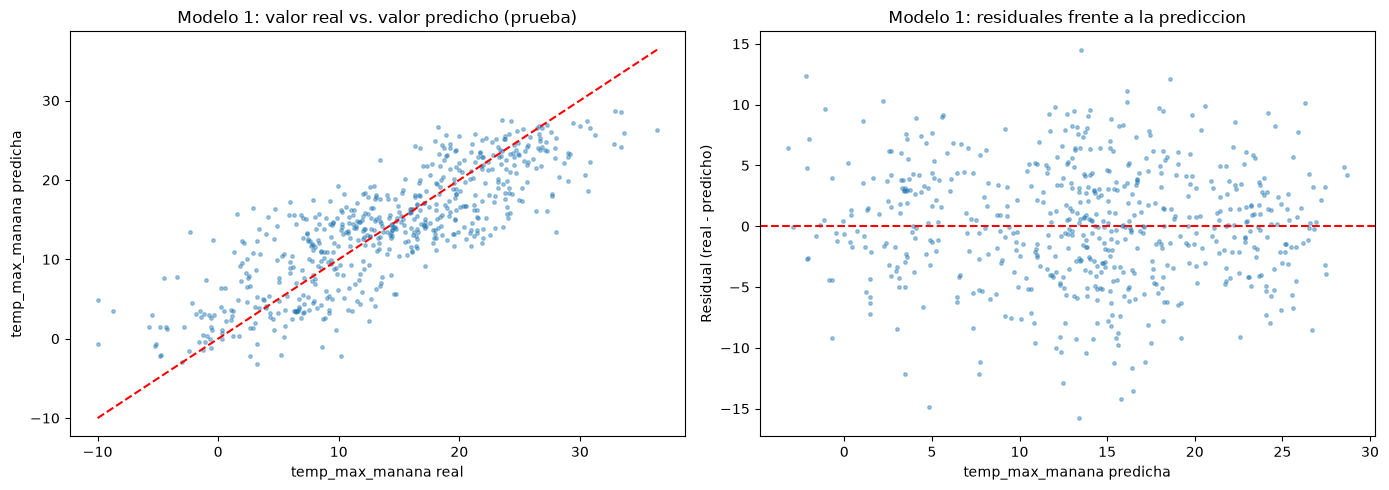

In [158]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test, y_test_pred_1, '.', alpha=0.4, markersize=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Modelo 1: valor real vs. valor predicho (prueba)')
plt.xlabel('temp_max_manana real')
plt.ylabel('temp_max_manana predicha')

plt.subplot(1, 2, 2)
residuales_1 = y_test - y_test_pred_1
plt.plot(y_test_pred_1, residuales_1, '.', alpha=0.4, markersize=5)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Modelo 1: residuales frente a la prediccion')
plt.xlabel('temp_max_manana predicha')
plt.ylabel('Residual (real - predicho)')

plt.tight_layout()
plt.show()

## 4.4 Análisis de los resultados del Modelo 1

El modelo llega a un RMSE de 4,87 grados sobre prueba, con R² de 0,68. O sea que las predicciones se desvían unos 4,9 °C del valor real y el modelo explica cerca del 68% de la variabilidad de la temperatura del día siguiente.

¿Es bueno eso? Depende de contra qué se compare. La desviación estándar de la variable objetivo ronda los 8,6 °C, que sería el RMSE de un modelo trivial que siempre predijera el promedio. El nuestro baja el error a poco más de la mitad, así que sí está aportando algo, pero equivocarse casi 5 °C sigue siendo mucho para el tipo de decisiones que AlpesPlanck quiere tomar.

No hay sobreajuste. Las métricas de entrenamiento y prueba se parecen mucho, con menos de una décima de grado de diferencia en el RMSE. Tampoco sorprende: son 31 coeficientes ajustados sobre 1.794 observaciones, casi sesenta veces más datos que parámetros.

Algo que llama la atención es que el error sobre prueba salga un poco más bajo que sobre entrenamiento. No es un error de cálculo ni quiere decir que el modelo prediga mejor lo que no ha visto. Lo que pasó es que la partición aleatoria dejó en prueba un conjunto con menos dispersión (8,64 de desviación estándar frente a 9,10 en entrenamiento), o sea un poco más fácil. Es ruido del muestreo y no cambia nada.

En el gráfico de real contra predicho los puntos siguen la diagonal pero con bastante dispersión. Se nota además que el modelo comprime el rango: casi no predice valores bajo 0 °C ni sobre 30 °C aunque en los datos sí existen. Es lo típico de un modelo al que le falta información para separar los casos extremos.

El gráfico de residuales no muestra curvatura, pero sí una banda ancha y bastante pareja. O sea que el error no depende del nivel de la predicción, simplemente es grande. 

## 5. Modelo 2 - Estrategia B: resolución mensual

## 5.1 Construcción del pipeline

Mantenemos la estructura del pipeline y se cambian tres elementos:

| Elemento | Modelo 1 (Estrategia A) | Modelo 2 (Estrategia B) |
|---|---|---|
| Representación del tiempo | `estacion_anio` — 4 categorías | `mes` - 12 categorías |
| Imputación numérica | Media | Mediana |
| Escalado | Min-Max | Estandarización|

Justificación de los cambios:

1. **`mes` en lugar de `estacion_anio`:** Es el cambio central. En la Parte II comprobamos que meses agrupados dentro de una misma estación difieren entre sí en varios grados (marzo, abril y mayo son los tres "primavera" pero su temperatura promedio no se parece). Al agruparlos, la Estrategia A obliga al modelo a asignarles un único coeficiente, lo que impide distinguir un día de marzo de uno de mayo. Con 12 categorías, el modelo estima un nivel base propio para cada mes y puede seguir el ciclo anual con mucha más fidelidad.
2. **Imputación por la mediana:** Es más robusta ante los valores atípicos legítimos que se conservaron deliberadamente en la Parte II (días reales de tormenta con vientos altos). Estos valores desplazan la media pero apenas afectan la mediana.
3. **Estandarización:** Deja todas las variables con media 0 y desviación 1, así que los coeficientes quedan expresados en unidades de desviación estándar y son directamente comparables entre sí. 

In [159]:
# --- Transformadores de la Estrategia B ---
numeric_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocesamiento_B = ColumnTransformer(transformers=[
    ("num", numeric_transformer_B, variables_numericas),
    ("cat", categorical_transformer_B, categoricas_B),
])

modelo_2 = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_B),
    ("modelo", LinearRegression()),
])

modelo_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 5.2 Entrenamiento y evaluación

In [160]:
modelo_2.fit(X_train, y_train)

nombres_B = modelo_2.named_steps['preprocesamiento'].get_feature_names_out()
regresion_B = modelo_2.named_steps['modelo']

print("Modelo 2 entrenado")
print(f"  Variables tras el preprocesamiento: {len(nombres_B)}")
print(f"  Coeficientes estimados            : {len(regresion_B.coef_)}")
print(f"  Intercepto                        : {regresion_B.intercept_:.4f}")

Modelo 2 entrenado
  Variables tras el preprocesamiento: 39
  Coeficientes estimados            : 39
  Intercepto                        : 13.7653


In [161]:
y_train_pred_2 = modelo_2.predict(X_train)
y_test_pred_2 = modelo_2.predict(X_test)

metricas_2 = pd.DataFrame({
    'Entrenamiento': calcular_metricas(y_train, y_train_pred_2),
    'Prueba': calcular_metricas(y_test, y_test_pred_2)
}).T

print("=== MODELO 2 — Estrategia B (resolucion mensual) ===")
print(metricas_2.round(4))
print()
print(f"Diferencia RMSE (prueba - entrenamiento): "
      f"{metricas_2.loc['Prueba','RMSE'] - metricas_2.loc['Entrenamiento','RMSE']:.4f}")
print(f"Diferencia R2   (prueba - entrenamiento): "
      f"{metricas_2.loc['Prueba','R2'] - metricas_2.loc['Entrenamiento','R2']:.4f}")

=== MODELO 2 — Estrategia B (resolucion mensual) ===
                  MAE      MSE    RMSE      R2
Entrenamiento  3.4304  18.5274  4.3043  0.7762
Prueba         3.3364  17.4399  4.1761  0.7661

Diferencia RMSE (prueba - entrenamiento): -0.1282
Diferencia R2   (prueba - entrenamiento): -0.0101


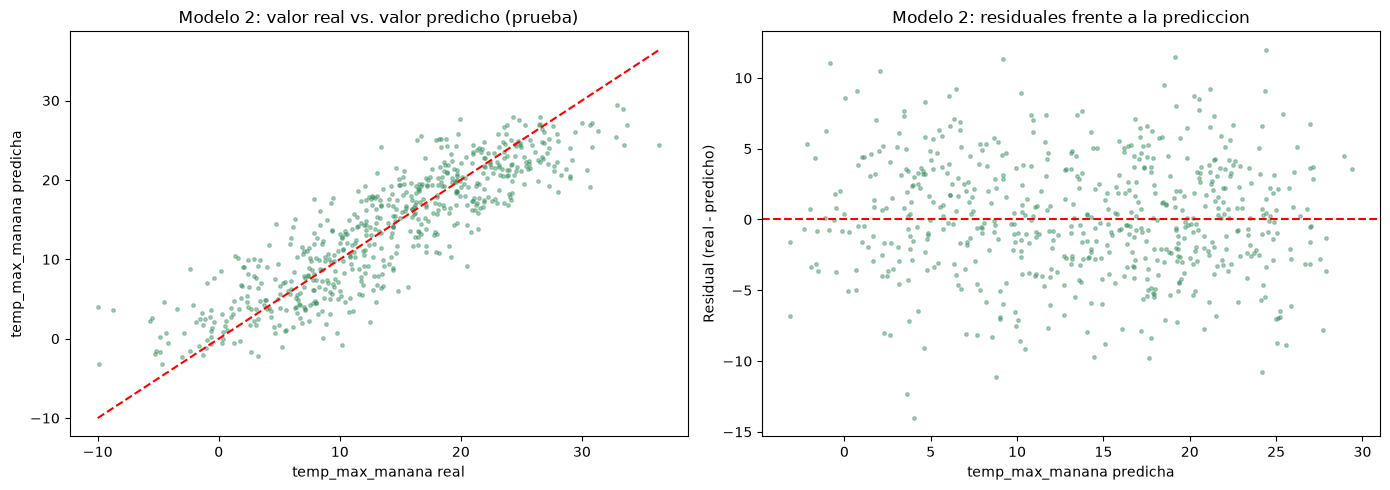

In [162]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test, y_test_pred_2, '.', alpha=0.4, markersize=5, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Modelo 2: valor real vs. valor predicho (prueba)')
plt.xlabel('temp_max_manana real')
plt.ylabel('temp_max_manana predicha')

plt.subplot(1, 2, 2)
residuales_2 = y_test - y_test_pred_2
plt.plot(y_test_pred_2, residuales_2, '.', alpha=0.4, markersize=5, color='seagreen')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Modelo 2: residuales frente a la prediccion')
plt.xlabel('temp_max_manana predicha')
plt.ylabel('Residual (real - predicho)')

plt.tight_layout()
plt.show()

## 5.3 Análisis de los resultados del Modelo 2

El RMSE baja a 4,18 grados y el R² sube a 0,77. Frente al Modelo 1 son 0,70 grados menos de error (un 14%) y 8,4 puntos más de variabilidad explicada.

Lo único que cambió con efecto real fue la resolución temporal. El modelo pasó de tener 4 niveles base, uno por estación, a tener 12, uno por mes, y así puede seguir el ciclo anual con una escalera de doce escalones en vez de cuatro. Como en la Parte I vimos que la estacionalidad es lo que más explica, subirle la resolución era lo que más podía ayudar.

Sobre los otros dos cambios hay que ser claros: casi no aportan. Cambiar media por mediana solo mueve unos pocos valores en columnas con pocos faltantes, y el escalado no cambia las métricas de una regresión lineal, porque al cambiar la escala de una variable su coeficiente cambia en la proporción inversa y la predicción queda igual. Sirve para interpretar, no para predecir mejor. Lo comprobamos abajo, porque decir que la mejora vino de los tres cambios por igual sería falso.

In [163]:
# Verificacion: aislar el efecto de cada cambio de la Estrategia B
def construir_pipeline(categoricas, imputador, escalador):
    pre = ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy=imputador)),
                          ("scaler", escalador)]), variables_numericas),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categoricas),
    ])
    return Pipeline([("preprocesamiento", pre), ("modelo", LinearRegression())])


configuraciones = [
    ("A completa: estacion + media + MinMax", categoricas_A, "mean", MinMaxScaler()),
    ("Solo cambia el tiempo: mes + media + MinMax", categoricas_B, "mean", MinMaxScaler()),
    ("Solo cambian imputador y escalador: estacion + mediana + Standard",
     categoricas_A, "median", StandardScaler()),
    ("B completa: mes + mediana + Standard", categoricas_B, "median", StandardScaler()),
]

filas = []
for nombre, cats, imp, esc in configuraciones:
    p = construir_pipeline(cats, imp, esc).fit(X_train, y_train)
    m = calcular_metricas(y_test, p.predict(X_test))
    filas.append({'Configuracion': nombre, 'RMSE': round(m['RMSE'], 4), 'R2': round(m['R2'], 4)})

print(pd.DataFrame(filas).to_string(index=False))

                                                    Configuracion   RMSE     R2
                            A completa: estacion + media + MinMax 4.8715 0.6817
                      Solo cambia el tiempo: mes + media + MinMax 4.1741 0.7663
Solo cambian imputador y escalador: estacion + mediana + Standard 4.8718 0.6817
                             B completa: mes + mediana + Standard 4.1761 0.7661


Cambiar únicamente la representación temporal reproduce prácticamente toda la mejora, mientras que cambiar solo el imputador y el escalador deja el resultado casi idéntico al de la Estrategia A. Queda establecido que la ingeniería de características sobre la variable temporal es lo que explica la diferencia entre los dos modelos, que es justo el aspecto que el enunciado señala como clave.

El gráfico de valor real contra predicho muestra los puntos más concentrados alrededor de la diagonal que en el Modelo 1, y el rango de predicciones se amplía: el modelo ya se atreve a predecir valores más bajos en invierno y más altos en verano. La compresión hacia el centro se reduce, aunque no desaparece.

Igual que en el Modelo 1, las métricas de entrenamiento y prueba son muy cercanas. Pasar de 31 a 39 coeficientes no deterioró la generalización: el aumento de complejidad se tradujo en mejor ajuste real y no en memorización.

## 6. Comparación de los dos modelos y selección

In [164]:
comparacion = pd.DataFrame({
    'Modelo 1 — Estrategia A (estacional)': calcular_metricas(y_test, y_test_pred_1),
    'Modelo 2 — Estrategia B (mensual)': calcular_metricas(y_test, y_test_pred_2),
}).T

print("=== Rendimiento sobre el conjunto de PRUEBA ===")
print(comparacion.round(4))

=== Rendimiento sobre el conjunto de PRUEBA ===
                                         MAE      MSE    RMSE      R2
Modelo 1 — Estrategia A (estacional)  3.8752  23.7315  4.8715  0.6817
Modelo 2 — Estrategia B (mensual)     3.3364  17.4399  4.1761  0.7661


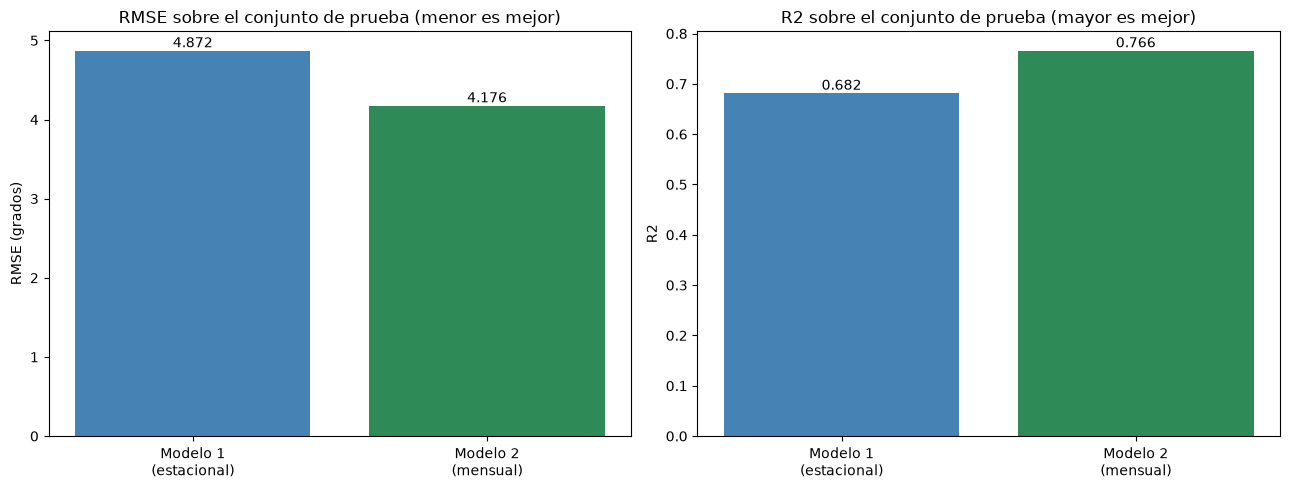

In [165]:
etiquetas = ['Modelo 1\n(estacional)', 'Modelo 2\n(mensual)']
valores_rmse = comparacion['RMSE'].values
valores_r2 = comparacion['R2'].values

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.bar(etiquetas, valores_rmse, color=['steelblue', 'seagreen'])
plt.title('RMSE sobre el conjunto de prueba (menor es mejor)')
plt.ylabel('RMSE (grados)')
for i, v in enumerate(valores_rmse):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.bar(etiquetas, valores_r2, color=['steelblue', 'seagreen'])
plt.title('R2 sobre el conjunto de prueba (mayor es mejor)')
plt.ylabel('R2')
for i, v in enumerate(valores_r2):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

El Modelo 2 (Estrategia B, resolución mensual) es el mejor de los dos: menor RMSE, menor MAE y mayor R² sobre el conjunto de prueba, sin señales de sobreajuste. Es el que vamos a usar para el análisis de importancia de variables y para generar las predicciones finales sobre los datos no etiquetados de AlpesPlanck.

# Actividad 4 y 5 - Tabla comparativa rendimiento modelos e importancia de variables